In [5]:
# ==============================================================================
# 🌌 FSD Engine (Фаза 5): РАДАР КАПИТУЛЯЦИИ (Боллинджер + 3 Вектора)
# Среда выполнения: Jupyter Notebook / Kaggle / Colab
# ==============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import math
from datetime import datetime, timedelta
import warnings
from tqdm.notebook import tqdm
from IPython.display import display, HTML

warnings.filterwarnings("ignore")

class FSD_MathV5:
    @staticmethod
    def calc_z_sigmoid(series: pd.Series) -> pd.Series:
        safe_series = np.maximum(series, 1e-9)
        log_s = np.log1p(safe_series)
        std_val = log_s.std()
        if std_val == 0: return pd.Series(0.5, index=series.index)
        z = (log_s - log_s.mean()) / std_val
        return (1 / (1 + np.exp(-z * 1.5))).round(4)

    @staticmethod
    def calc_atr(high, low, close, period=14):
        if len(close) < 2: return 0.0
        hl = high - low
        hc = np.abs(high - close.shift())
        lc = np.abs(low - close.shift())
        tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
        return float(tr.rolling(period, min_periods=1).mean().iloc[-1])

    @staticmethod
    def calc_bollinger_b(close_series: pd.Series, period=20, std_dev=2):
        """Возвращает %B. Если < 0, цена пробила нижнюю границу."""
        if len(close_series) < period: return 0.5
        sma = close_series.rolling(window=period).mean()
        std = close_series.rolling(window=period).std()
        upper = sma + (std * std_dev)
        lower = sma - (std * std_dev)
        
        last_c, last_u, last_l = close_series.iloc[-1], upper.iloc[-1], lower.iloc[-1]
        if last_u - last_l == 0: return 0.5
        percent_b = (last_c - last_l) / (last_u - last_l)
        return round(percent_b, 4)

class EngineV5:
    def __init__(self, tickers: list):
        self.tickers = list(set(tickers))
        self.raw_data = []
        self.df = pd.DataFrame()
        
    def scan_universe(self, days: int = 90):
        display(HTML(f"<p style='color:#3498db; font-weight:bold;'>[*] Фаза 5: Запуск 3D-Радара (Загрузка {len(self.tickers)} активов)...</p>"))
        end_date = datetime.now()
        start_date = end_date - timedelta(days=days)
        
        try:
            data = yf.download(self.tickers, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), progress=False)
        except Exception as e:
            display(HTML(f"<p style='color:#e74c3c;'>[!] Ошибка API: {e}</p>"))
            return

        for ticker in tqdm(self.tickers, desc="Извлечение Пространственных Метрик"):
            try:
                if isinstance(data.columns, pd.MultiIndex):
                    if ticker in data.columns.get_level_values(1): hist = data.xs(ticker, axis=1, level=1)
                    elif ticker in data.columns.get_level_values(0): hist = data[ticker]
                    else: continue
                else: hist = data

                hist = hist.dropna()
                if len(hist) < 30: continue
                
                c, v, h, l = hist['Close'], hist['Volume'], hist['High'], hist['Low']
                last_c, prev_c = float(c.iloc[-1]), float(c.iloc[-2])
                
                # Анти-Бан Капитализации
                tick_obj = yf.Ticker(ticker)
                try: cap = tick_obj.fast_info.get('marketCap', 0)
                except: cap = 0
                if cap == 0 or pd.isna(cap): cap = last_c * float(v.iloc[-1]) * 100 
                
                # --- СИСТЕМА ТРЕХ ВЕКТОРОВ ---
                # Вектор 1 (Микро-импульс за день)
                atr = FSD_MathV5.calc_atr(h, l, c)
                delta_1d = last_c - prev_c
                v1 = 0 if abs(delta_1d) <= (atr / 2.0) else (1 if delta_1d > 0 else -1)
                
                # Вектор 2 (Макро-инерция за 3 дня)
                delta_3d = last_c - float(c.iloc[-4])
                v2 = 1 if delta_3d > 0 else -1
                
                # Вектор 3 (Позиция в канале Боллинджера: %B)
                percent_b = FSD_MathV5.calc_bollinger_b(c)
                
                self.raw_data.append({
                    "Ticker": ticker,
                    "Price": round(last_c, 2),
                    "Cap_Raw": cap,
                    "Vol_Raw": float(v.iloc[-1]) * last_c,
                    "Vector_1": v1,
                    "Vector_2": v2,
                    "Percent_B": percent_b
                })
            except Exception: continue
                
        self.df = pd.DataFrame(self.raw_data)

    def process_logic(self):
        if self.df.empty: return
        self.df["P_Cap"] = FSD_MathV5.calc_z_sigmoid(self.df["Cap_Raw"])
        self.df["P_Vol"] = FSD_MathV5.calc_z_sigmoid(self.df["Vol_Raw"])
        
        classify = lambda p: "F" if p >= 0.65 else ("SD" if p >= 0.35 else "A")
        self.df["Mass"] = self.df["P_Cap"].apply(classify)
        self.df["Kinetic"] = self.df["P_Vol"].apply(classify)
        
        alerts = []
        for _, r in self.df.iterrows():
            # ЛОГИКА КАПИТУЛЯЦИИ (3 Вектора сошлись)
            # 1. Огромный объем (Kinetic == F)
            # 2. Цена остановилась сегодня (Vector_1 == 0)
            # 3. До этого цена падала (Vector_2 == -1)
            # 4. Цена пробила или касается дна Боллинджера (Percent_B <= 0.15)
            if r['Kinetic'] == "F" and r['Vector_1'] == 0 and r['Vector_2'] == -1 and r['Percent_B'] <= 0.15:
                alerts.append(f"🔥 <b>КВАНТОВАЯ КАПИТУЛЯЦИЯ | {r['Ticker']}</b> (${r['Price']}): Умные деньги ловят падающий нож на дне Боллинджера (%B: {r['Percent_B']}).")
                
        if alerts: display(HTML("<h3>🚨 НАЙДЕНЫ СИГНАЛЫ:</h3><ul>" + "".join([f"<li>{a}</li>" for a in alerts]) + "</ul>"))
        else: display(HTML("<h3>🚨 НАЙДЕНЫ СИГНАЛЫ:</h3><p>Условий для идеальной капитуляции сегодня нет.</p>"))
            
        display(HTML("<h3>📊 КАРТА ТРЕХ ВЕКТОРОВ</h3>"))
        out = self.df[['Ticker', 'Price', 'Mass', 'Kinetic', 'Vector_1', 'Vector_2', 'Percent_B']].sort_values('Percent_B')
        styled = out.style.background_gradient(subset=['Percent_B'], cmap='coolwarm')
        display(styled)

# ЗАПУСК (Используем твой список)
TICKERS = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "AMD", "INTC", "CRM", "NFLX", "TSLA", "PLTR", "UBER", "COIN", "HOOD", "RIVN", "GME", "AMC", "DJT", "MSTR", "CVNA", "BTC-USD", "ETH-USD", "SOL-USD"]
scanner = EngineV5(TICKERS)
scanner.scan_universe()
scanner.process_logic()

Извлечение Пространственных Метрик:   0%|          | 0/23 [00:00<?, ?it/s]

,Ticker,Price,Mass,Kinetic,Vector_1,Vector_2,Percent_B
17,AAPL,250.120000,F,SD,-1,-1,-0.035200
4,TSLA,391.200000,SD,SD,0,-1,0.059800
10,DJT,9.800000,A,A,0,-1,0.082800
16,CVNA,300.150000,A,A,0,-1,0.096800
18,AMC,1.090000,A,A,0,-1,0.112500
7,AMD,193.390000,SD,SD,0,-1,0.155200
13,HOOD,73.390000,A,SD,-1,-1,0.162200
20,GME,23.530000,A,A,-1,-1,0.217000
3,RIVN,14.860000,A,A,-1,-1,0.246400
6,NVDA,180.250000,F,SD,0,-1,0.257100


In [6]:
# ==============================================================================
# 🌌 FSD Engine: БЭКТЕСТЕР ФАЗЫ 5 (Проверка гипотезы 3 Векторов)
# ==============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from tqdm.notebook import tqdm
from IPython.display import display, HTML

warnings.filterwarnings("ignore")

class BacktestV5:
    def __init__(self, tickers: list, years: int = 2):
        self.tickers = list(set(tickers))
        self.days = years * 252
        self.results = []
        
    def run(self):
        display(HTML(f"<p style='color:#3498db; font-weight:bold;'>[*] Симуляция Машины Времени ({self.days} дней)... Ждем сужения фильтра.</p>"))
        try: data = yf.download(self.tickers, period=f"{self.days}d", progress=False)
        except Exception as e: return
        
        for ticker in tqdm(self.tickers, desc="Прогон истории"):
            if isinstance(data.columns, pd.MultiIndex):
                if ticker in data.columns.get_level_values(1): df = data.xs(ticker, axis=1, level=1)
                elif ticker in data.columns.get_level_values(0): df = data[ticker]
                else: continue
            else: df = data

            df = df.dropna().copy()
            if len(df) < 60: continue

            # 1. Кинетика (Объем)
            df['Vol_USD'] = df['Close'] * df['Volume']
            roll_std = df['Vol_USD'].rolling(60).std().replace(0, 1e-9)
            z_scores = (df['Vol_USD'] - df['Vol_USD'].rolling(60).mean()) / roll_std
            df['P_Vol'] = 1 / (1 + np.exp(-z_scores * 1.5))
            
            # 2. Боллинджер (%B)
            sma20 = df['Close'].rolling(20).mean()
            std20 = df['Close'].rolling(20).std()
            lower_bb = sma20 - (std20 * 2)
            upper_bb = sma20 + (std20 * 2)
            # Защита от деления на ноль, если свечи плоские
            bb_diff = (upper_bb - lower_bb).replace(0, 1e-9)
            df['Percent_B'] = (df['Close'] - lower_bb) / bb_diff
            
            # 3. Вектора
            # Микро (1 день)
            hl = df['High'] - df['Low']
            hc = np.abs(df['High'] - df['Close'].shift())
            lc = np.abs(df['Low'] - df['Close'].shift())
            df['ATR'] = pd.concat([hl, hc, lc], axis=1).max(axis=1).rolling(14).mean()
            df['Delta_1d'] = df['Close'].diff()
            df['Vector_1'] = np.select([df['Delta_1d'] >= df['ATR']/2, df['Delta_1d'] <= -df['ATR']/2], [1, -1], default=0)
            
            # Макро (3 дня)
            df['Vector_2'] = np.where(df['Close'].diff(3) > 0, 1, -1)
            
            # 4. ФИЛЬТР КАПИТУЛЯЦИИ
            signals = df[(df['P_Vol'] >= 0.65) & (df['Vector_1'] == 0) & (df['Vector_2'] == -1) & (df['Percent_B'] <= 0.15)]
            
            # Собираем форвардные возвраты
            for idx, row in signals.iterrows():
                loc = df.index.get_loc(idx)
                ret_5 = (df['Close'].iloc[loc+5] / row['Close'] - 1)*100 if loc+5 < len(df) else None
                ret_10 = (df['Close'].iloc[loc+10] / row['Close'] - 1)*100 if loc+10 < len(df) else None
                ret_20 = (df['Close'].iloc[loc+20] / row['Close'] - 1)*100 if loc+20 < len(df) else None
                
                self.results.append({
                    "Ticker": ticker, "Date": idx.strftime('%Y-%m-%d'), "Price": round(row['Close'], 2),
                    "T+5": ret_5, "T+10": ret_10, "T+20": ret_20
                })

    def analyze(self):
        res = pd.DataFrame(self.results).dropna()
        if res.empty:
            display(HTML("<h3>Событий жесткой капитуляции в истории не найдено. Фильтр слишком строг.</h3>"))
            return
            
        display(HTML(f"<h3>📊 ИТОГИ БЭКТЕСТА (Найдено {len(res)} ювелирных сигналов)</h3>"))
        
        w_5, w_10, w_20 = (res['T+5']>0).mean()*100, (res['T+10']>0).mean()*100, (res['T+20']>0).mean()*100
        m_5, m_10, m_20 = res['T+5'].mean(), res['T+10'].mean(), res['T+20'].mean()

        html = f"""
        <table style="width:100%; text-align: center; border: 1px solid #ddd;">
            <tr style="background:#2c3e50; color:white;"><th>Горизонт</th><th>WinRate</th><th>Ср. Доходность</th></tr>
            <tr><td>T+5</td><td style="color:{'#2ecc71' if w_5>50 else '#e74c3c'}">{w_5:.1f}%</td><td>{m_5:.2f}%</td></tr>
            <tr><td>T+10</td><td style="color:{'#2ecc71' if w_10>50 else '#e74c3c'}">{w_10:.1f}%</td><td>{m_10:.2f}%</td></tr>
            <tr><td>T+20 (Месяц)</td><td style="color:{'#2ecc71' if w_20>50 else '#e74c3c'}"><b>{w_20:.1f}%</b></td><td><b>{m_20:.2f}%</b></td></tr>
        </table>
        """
        display(HTML(html))
        
        display(HTML("<h4>🏆 Все сделки Капитуляции (Сортировка по T+20):</h4>"))
        styled = res.sort_values("T+20", ascending=False).style.background_gradient(subset=['T+5', 'T+10', 'T+20'], cmap='RdYlGn').format({'T+5': '{:+.2f}%', 'T+10': '{:+.2f}%', 'T+20': '{:+.2f}%'})
        display(styled)

# ЗАПУСК
tester = BacktestV5(TICKERS, years=2)
tester.run()
tester.analyze()

Прогон истории:   0%|          | 0/23 [00:00<?, ?it/s]

Горизонт,WinRate,Ср. Доходность
T+5,54.9%,1.83%
T+10,56.3%,1.99%
T+20 (Месяц),51.4%,2.74%


,Ticker,Date,Price,T+5,T+10,T+20
60,PLTR,2024-11-04,41.410000,+45.47%,+47.94%,+71.36%
90,HOOD,2024-11-01,23.970000,+27.41%,+34.84%,+56.95%
121,SOL-USD,2025-04-07,106.900000,+23.72%,+26.00%,+38.67%
92,HOOD,2025-04-07,35.410000,+24.65%,+18.86%,+37.50%
97,ETH-USD,2025-06-22,2228.210000,+8.78%,+15.40%,+32.07%
127,NFLX,2025-04-07,86.780000,+7.31%,+19.88%,+31.10%
9,UBER,2025-04-07,65.640000,+11.37%,+13.41%,+30.76%
59,PLTR,2024-08-05,24.090000,+21.96%,+34.91%,+26.65%
104,CVNA,2025-01-02,199.560000,-3.26%,+15.50%,+26.09%
62,DJT,2024-06-21,27.660000,+18.40%,+9.62%,+25.45%


In [7]:
# ==============================================================================
# 🌌 FSD Engine (Фаза 6): СЕГМЕНТАТОР МАССЫ (Вскрытие Бэктеста)
# Инструкция: Запускать СТРОГО после того, как отработала ячейка с Бэктестером
# ==============================================================================

import pandas as pd
import yfinance as yf
import numpy as np
from IPython.display import display, HTML
import warnings

warnings.filterwarnings("ignore")

# Проверяем, лежат ли в памяти результаты работы предыдущей ячейки
if 'tester' not in globals() or not tester.results:
    display(HTML("<p style='color:#e74c3c;'>[!] Ошибка: Сначала запустите ячейку с Бэктестером (переменная tester не найдена).</p>"))
else:
    display(HTML("<p style='color:#3498db; font-weight:bold;'>[*] Запуск Анализатора. Сортировка аномалий по Истинной Массе...</p>"))
    
    # Загружаем чистые результаты бэктеста
    res_df = pd.DataFrame(tester.results).dropna()
    unique_tickers = res_df['Ticker'].unique()
    
    # 1. Быстро определяем текущую массу (Капитализацию) для тикеров из бэктеста
    mass_data = []
    for ticker in unique_tickers:
        try:
            # Используем fast_info чтобы не словить бан
            cap = yf.Ticker(ticker).fast_info.get('marketCap', 0)
            if cap == 0 or pd.isna(cap):
                cap = 1e9 # Заглушка для крипты (гарантированно отправит ее в класс A)
            mass_data.append({'Ticker': ticker, 'Cap_Raw': cap})
        except:
            mass_data.append({'Ticker': ticker, 'Cap_Raw': 1e9})
            
    mass_df = pd.DataFrame(mass_data)
    
    # 2. Применяем Z-Сигмоиду для классификации
    safe_series = np.maximum(mass_df['Cap_Raw'], 1e-9)
    log_s = np.log1p(safe_series)
    
    # Защита от деления на ноль, если тикеров мало
    std_val = log_s.std() if log_s.std() > 0 else 1 
    z = (log_s - log_s.mean()) / std_val
    mass_df['P_Cap'] = (1 / (1 + np.exp(-z * 1.5))).round(4)
    
    def classify_mass(p):
        if p >= 0.65: return "F (Институциональные Гиганты)"
        elif p >= 0.35: return "SD (Середняки)"
        else: return "A (Мемы и Крипта)"
        
    mass_df['Mass_Class'] = mass_df['P_Cap'].apply(classify_mass)
    
    # 3. Объединяем результаты бэктеста с классом массы
    merged_df = pd.merge(res_df, mass_df[['Ticker', 'Mass_Class']], on='Ticker', how='left')
    
    # 4. Выводим красивую аналитику
    display(HTML("<h3>🔬 РЕЗУЛЬТАТЫ ПО КЛАССАМ АКТИВОВ: Кто тянет стратегию на дно?</h3>"))
    
    html = "<table style='width:100%; border-collapse: collapse; text-align: center; margin-bottom: 20px; font-family: sans-serif;'>"
    html += "<tr style='background-color: #2c3e50; color: white; border-bottom: 2px solid #ecf0f1;'>"
    html += "<th style='padding: 12px;'>Класс Актива</th><th style='padding: 12px;'>Кол-во Сигналов</th>"
    html += "<th style='padding: 12px;'>WinRate (T+5)</th><th style='padding: 12px;'>WinRate (T+10)</th><th style='padding: 12px;'>WinRate (T+20)</th>"
    html += "<th style='padding: 12px;'>Ср. Доходность (Месяц)</th></tr>"
    
    classes = ["F (Институциональные Гиганты)", "SD (Середняки)", "A (Мемы и Крипта)"]
    
    for c in classes:
        subset = merged_df[merged_df['Mass_Class'] == c]
        if subset.empty: continue
        
        count = len(subset)
        w5 = (subset['T+5'] > 0).mean() * 100
        w10 = (subset['T+10'] > 0).mean() * 100
        w20 = (subset['T+20'] > 0).mean() * 100
        m20 = subset['T+20'].mean()
        
        # Динамическая раскраска (Зеленый если WinRate > 60%)
        c_w20 = '#2ecc71' if w20 >= 60 else ('#f39c12' if w20 >= 50 else '#e74c3c')
        c_m20 = '#2ecc71' if m20 > 0 else '#e74c3c'
        
        html += f"<tr style='border-bottom: 1px solid #bdc3c7; background-color: #1e1e1e;'>"
        html += f"<td style='padding: 10px; font-weight: bold; color: white;'>{c}</td>"
        html += f"<td style='padding: 10px; color: #ecf0f1;'>{count}</td>"
        html += f"<td style='padding: 10px; color: #ecf0f1;'>{w5:.1f}%</td>"
        html += f"<td style='padding: 10px; color: #ecf0f1;'>{w10:.1f}%</td>"
        html += f"<td style='padding: 10px; color:{c_w20}; font-weight:bold; font-size: 1.1em;'>{w20:.1f}%</td>"
        html += f"<td style='padding: 10px; color:{c_m20}; font-weight:bold;'>{m20:.2f}%</td>"
        html += "</tr>"
        
    html += "</table>"
    display(HTML(html))
    
    display(HTML("""
    <div style='background-color: #2c3e50; padding: 15px; border-left: 5px solid #f1c40f; color: #ecf0f1; border-radius: 4px;'>
        <h4 style='margin-top:0; color: #f1c40f;'>💡 Ожидаемый Инсайт:</h4>
        <p>Обратите внимание на колонку <b>WinRate (T+20)</b>. Мы ожидаем увидеть четкую корреляцию:</p>
        <ul style='margin-bottom:0;'>
            <li>У <b>Гигантов (F)</b> пробой Боллинджера на объеме — это реальная капитуляция. Там сидят "умные деньги", которые выкупают просадку. WinRate должен быть высоким.</li>
            <li>У <b>Крипты/Мемов (A)</b> пробой Боллинджера — это каскад маржин-коллов ритейла. Цена пробивает дно и летит искать новое. WinRate будет ниже 50%.</li>
        </ul>
    </div>
    """))

Класс Актива,Кол-во Сигналов,WinRate (T+5),WinRate (T+10),WinRate (T+20),Ср. Доходность (Месяц)
F (Институциональные Гиганты),67,61.2%,64.2%,58.2%,4.44%
SD (Середняки),37,51.4%,59.5%,59.5%,5.71%
A (Мемы и Крипта),38,47.4%,39.5%,31.6%,-3.14%


In [8]:
# ==============================================================================
# 🌌 FSD Engine (Фаза 7): РАДАР ЭЙФОРИИ И РАСПРЕДЕЛЕНИЯ (Поиск Вершин)
# Интегрированный Бэктест + Сегментатор Истинной Массы
# ==============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from tqdm.notebook import tqdm
from IPython.display import display, HTML

warnings.filterwarnings("ignore")

class DistributionBacktester:
    def __init__(self, tickers: list, years: int = 2):
        self.tickers = list(set(tickers))
        self.days = years * 252
        self.results = []
        self.mass_data = []
        
    def run_simulation(self):
        display(HTML(f"<p style='color:#e74c3c; font-weight:bold;'>[*] Симуляция Эйфории. Ищем точки разгрузки Умных Денег...</p>"))
        try: 
            data = yf.download(self.tickers, period=f"{self.days}d", progress=False)
        except Exception as e: 
            return

        for ticker in tqdm(self.tickers, desc="Анализ Эйфории"):
            # 1. Сбор Истинной Массы (Капитализации)
            try:
                cap = yf.Ticker(ticker).fast_info.get('marketCap', 0)
                if cap == 0 or pd.isna(cap): cap = 1e9
            except: cap = 1e9
            self.mass_data.append({'Ticker': ticker, 'Cap_Raw': cap})
            
            # 2. Распаковка цен
            if isinstance(data.columns, pd.MultiIndex):
                if ticker in data.columns.get_level_values(1): df = data.xs(ticker, axis=1, level=1)
                elif ticker in data.columns.get_level_values(0): df = data[ticker]
                else: continue
            else: df = data

            df = df.dropna().copy()
            if len(df) < 60: continue

            # --- ФИЗИКА ВЕРШИНЫ ---
            
            # Кинетика
            df['Vol_USD'] = df['Close'] * df['Volume']
            roll_std = df['Vol_USD'].rolling(60).std().replace(0, 1e-9)
            z_scores = (df['Vol_USD'] - df['Vol_USD'].rolling(60).mean()) / roll_std
            df['P_Vol'] = 1 / (1 + np.exp(-z_scores * 1.5))
            
            # Верхний Боллинджер (%B)
            sma20 = df['Close'].rolling(20).mean()
            std20 = df['Close'].rolling(20).std()
            lower_bb = sma20 - (std20 * 2)
            upper_bb = sma20 + (std20 * 2)
            bb_diff = (upper_bb - lower_bb).replace(0, 1e-9)
            df['Percent_B'] = (df['Close'] - lower_bb) / bb_diff
            
            # Вектора (Остановка на росте)
            hl = df['High'] - df['Low']
            hc = np.abs(df['High'] - df['Close'].shift())
            lc = np.abs(df['Low'] - df['Close'].shift())
            df['ATR'] = pd.concat([hl, hc, lc], axis=1).max(axis=1).rolling(14).mean()
            
            df['Delta_1d'] = df['Close'].diff()
            df['Vector_1'] = np.select([df['Delta_1d'] >= df['ATR']/2, df['Delta_1d'] <= -df['ATR']/2], [1, -1], default=0)
            
            # Вектор 2: Цена до этого РОСЛА (а не падала)
            df['Vector_2'] = np.where(df['Close'].diff(3) > 0, 1, -1)
            
            # ЛОГИКА РАСПРЕДЕЛЕНИЯ: Огромный объем, Вектор 0, Рост, %B у потолка (>= 0.85)
            signals = df[(df['P_Vol'] >= 0.65) & (df['Vector_1'] == 0) & (df['Vector_2'] == 1) & (df['Percent_B'] >= 0.85)]
            
            for idx, row in signals.iterrows():
                loc = df.index.get_loc(idx)
                ret_5 = (df['Close'].iloc[loc+5] / row['Close'] - 1)*100 if loc+5 < len(df) else None
                ret_10 = (df['Close'].iloc[loc+10] / row['Close'] - 1)*100 if loc+10 < len(df) else None
                ret_20 = (df['Close'].iloc[loc+20] / row['Close'] - 1)*100 if loc+20 < len(df) else None
                
                self.results.append({
                    "Ticker": ticker, "Date": idx.strftime('%Y-%m-%d'), "Price": round(row['Close'], 2),
                    "T+5": ret_5, "T+10": ret_10, "T+20": ret_20
                })

    def analyze_segments(self):
        res_df = pd.DataFrame(self.results).dropna()
        mass_df = pd.DataFrame(self.mass_data)
        
        if res_df.empty:
            display(HTML("<h3>Событий Распределения не найдено.</h3>"))
            return
            
        # Классификация Массы
        safe_series = np.maximum(mass_df['Cap_Raw'], 1e-9)
        log_s = np.log1p(safe_series)
        std_val = log_s.std() if log_s.std() > 0 else 1 
        z = (log_s - log_s.mean()) / std_val
        mass_df['P_Cap'] = (1 / (1 + np.exp(-z * 1.5))).round(4)
        
        def classify_mass(p):
            if p >= 0.65: return "F (Институциональные Гиганты)"
            elif p >= 0.35: return "SD (Середняки)"
            else: return "A (Мемы и Крипта)"
            
        mass_df['Mass_Class'] = mass_df['P_Cap'].apply(classify_mass)
        merged_df = pd.merge(res_df, mass_df[['Ticker', 'Mass_Class']], on='Ticker', how='left')
        
        display(HTML("<h3>📉 РАДАР ЭЙФОРИИ: Кто падает после распределения объемов?</h3>"))
        display(HTML("<p><b>Внимание:</b> Здесь <b>WinRate</b> — это процент случаев, когда цена <b>УПАЛА</b> (идеально для Шорта/Продажи). Ср. Доходность должна быть отрицательной (красной).</p>"))
        
        html = "<table style='width:100%; border-collapse: collapse; text-align: center; margin-bottom: 20px; font-family: sans-serif;'>"
        html += "<tr style='background-color: #8e44ad; color: white; border-bottom: 2px solid #ecf0f1;'>"
        html += "<th style='padding: 12px;'>Класс Актива</th><th style='padding: 12px;'>Сигналов (Вершин)</th>"
        html += "<th style='padding: 12px;'>Short WinRate (T+5)</th><th style='padding: 12px;'>Short WinRate (T+10)</th><th style='padding: 12px;'>Short WinRate (T+20)</th>"
        html += "<th style='padding: 12px;'>Ср. Изменение (Месяц)</th></tr>"
        
        classes = ["F (Институциональные Гиганты)", "SD (Середняки)", "A (Мемы и Крипта)"]
        
        for c in classes:
            subset = merged_df[merged_df['Mass_Class'] == c]
            if subset.empty: continue
            
            count = len(subset)
            # Успех = цена упала (доходность < 0)
            w5 = (subset['T+5'] < 0).mean() * 100
            w10 = (subset['T+10'] < 0).mean() * 100
            w20 = (subset['T+20'] < 0).mean() * 100
            m20 = subset['T+20'].mean()
            
            # Зеленый если Short WinRate > 60% (значит паттерн отлично ловит разворот вниз)
            c_w20 = '#2ecc71' if w20 >= 60 else ('#f39c12' if w20 >= 50 else '#e74c3c')
            # Для изменения цены мы хотим видеть минус (красный/зеленый для шорта)
            c_m20 = '#2ecc71' if m20 < 0 else '#e74c3c' 
            
            html += f"<tr style='border-bottom: 1px solid #bdc3c7; background-color: #1e1e1e;'>"
            html += f"<td style='padding: 10px; font-weight: bold; color: white;'>{c}</td>"
            html += f"<td style='padding: 10px; color: #ecf0f1;'>{count}</td>"
            html += f"<td style='padding: 10px; color: #ecf0f1;'>{w5:.1f}%</td>"
            html += f"<td style='padding: 10px; color: #ecf0f1;'>{w10:.1f}%</td>"
            html += f"<td style='padding: 10px; color:{c_w20}; font-weight:bold; font-size: 1.1em;'>{w20:.1f}%</td>"
            html += f"<td style='padding: 10px; color:{c_m20}; font-weight:bold;'>{m20:.2f}%</td>"
            html += "</tr>"
            
        html += "</table>"
        display(HTML(html))

# ЗАПУСК
TICKERS = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "AMD", "INTC", "CRM", "NFLX", "TSLA", "PLTR", "UBER", "COIN", "HOOD", "RIVN", "GME", "AMC", "DJT", "MSTR", "CVNA", "BTC-USD", "ETH-USD", "SOL-USD"]
dist_tester = DistributionBacktester(TICKERS, years=2)
dist_tester.run_simulation()
dist_tester.analyze_segments()

Анализ Эйфории:   0%|          | 0/23 [00:00<?, ?it/s]

Класс Актива,Сигналов (Вершин),Short WinRate (T+5),Short WinRate (T+10),Short WinRate (T+20),Ср. Изменение (Месяц)
F (Институциональные Гиганты),106,42.5%,34.0%,29.2%,5.11%
SD (Середняки),71,46.5%,40.8%,43.7%,8.61%
A (Мемы и Крипта),77,46.8%,49.4%,58.4%,-1.92%


In [10]:
# ==============================================================================
# 🌌 FSD Engine (Phase 8): PRODUCTION TERMINAL (Снайперский Сканер)
# Описание: Ежедневный радар для поиска идеальных аномалий (Long/Short)
# ==============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from datetime import datetime, timedelta
from tqdm.notebook import tqdm
from IPython.display import display, HTML

warnings.filterwarnings("ignore")

class FSD_MathProd:
    @staticmethod
    def calc_z_sigmoid(series: pd.Series) -> pd.Series:
        safe_series = np.maximum(series, 1e-9)
        log_s = np.log1p(safe_series)
        std_val = log_s.std()
        if std_val == 0: return pd.Series(0.5, index=series.index)
        z = (log_s - log_s.mean()) / std_val
        return (1 / (1 + np.exp(-z * 1.5))).round(4)

    @staticmethod
    def calc_atr(high, low, close, period=14):
        if len(close) < 2: return 0.0
        hl = high - low
        hc = np.abs(high - close.shift())
        lc = np.abs(low - close.shift())
        tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
        return float(tr.rolling(period, min_periods=1).mean().iloc[-1])

    @staticmethod
    def calc_bollinger_b(close_series: pd.Series, period=20, std_dev=2):
        if len(close_series) < period: return 0.5
        sma = close_series.rolling(window=period).mean()
        std = close_series.rolling(window=period).std()
        upper = sma + (std * std_dev)
        lower = sma - (std * std_dev)
        last_c, last_u, last_l = close_series.iloc[-1], upper.iloc[-1], lower.iloc[-1]
        if last_u - last_l == 0: return 0.5
        return round((last_c - last_l) / (last_u - last_l), 4)

class FSD_Terminal:
    def __init__(self, tickers: list):
        self.tickers = list(set(tickers))
        self.raw_data = []
        self.df = pd.DataFrame()
        
    def scan_market(self, days: int = 60):
        display(HTML(f"<h2>🚀 FSD TERMINAL: Запуск сканирования ({len(self.tickers)} активов)...</h2>"))
        
        end_date = datetime.now()
        start_date = end_date - timedelta(days=days)
        
        try:
            data = yf.download(self.tickers, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), progress=False)
        except Exception as e:
            display(HTML(f"<p style='color:#e74c3c;'>[!] Ошибка API: {e}</p>"))
            return

        for ticker in tqdm(self.tickers, desc="Синтез данных"):
            try:
                if isinstance(data.columns, pd.MultiIndex):
                    if ticker in data.columns.get_level_values(1): hist = data.xs(ticker, axis=1, level=1)
                    elif ticker in data.columns.get_level_values(0): hist = data[ticker]
                    else: continue
                else: hist = data

                hist = hist.dropna()
                if len(hist) < 30: continue
                
                c, v, h, l = hist['Close'], hist['Volume'], hist['High'], hist['Low']
                last_c, prev_c = float(c.iloc[-1]), float(c.iloc[-2])
                
                # Истинная Масса
                try: cap = yf.Ticker(ticker).fast_info.get('marketCap', 0)
                except: cap = 0
                if cap == 0 or pd.isna(cap): cap = 1e9 # Мусор/Крипта
                
                # Вектор 1 (Остановка)
                atr = FSD_MathProd.calc_atr(h, l, c)
                delta_1d = last_c - prev_c
                v1 = 0 if abs(delta_1d) <= (atr / 2.0) else (1 if delta_1d > 0 else -1)
                
                # Вектор 2 (Тренд за 3 дня)
                v2 = 1 if (last_c - float(c.iloc[-4])) > 0 else -1
                
                # Боллинджер
                percent_b = FSD_MathProd.calc_bollinger_b(c)
                
                self.raw_data.append({
                    "Ticker": ticker, "Price": round(last_c, 2),
                    "Cap_Raw": cap, "Vol_Raw": float(v.iloc[-1]) * last_c,
                    "Vector_1": v1, "Vector_2": v2, "Percent_B": percent_b
                })
            except Exception: continue
                
        self.df = pd.DataFrame(self.raw_data)

    def generate_signals(self):
        if self.df.empty: return
        
        # Квантование Массы и Кинетики
        self.df["P_Cap"] = FSD_MathProd.calc_z_sigmoid(self.df["Cap_Raw"])
        self.df["P_Vol"] = FSD_MathProd.calc_z_sigmoid(self.df["Vol_Raw"])
        
        classify = lambda p: "F" if p >= 0.65 else ("SD" if p >= 0.35 else "A")
        self.df["Mass"] = self.df["P_Cap"].apply(classify)
        self.df["Kinetic"] = self.df["P_Vol"].apply(classify)
        
        long_signals = []
        short_signals = []
        
        for _, r in self.df.iterrows():
            t, p, m, k = r['Ticker'], r['Price'], r['Mass'], r['Kinetic']
            v1, v2, pb = r['Vector_1'], r['Vector_2'], r['Percent_B']
            
            # 🟢 СТРАТЕГИЯ LONG: Капитуляция Гигантов
            # Условия: Гигант (F), Огромный объем (F), Падал (v2=-1), Останов (v1=0), Дно Боллинджера (pb<=0.15)
            if m == "F" and k == "F" and v2 == -1 and v1 == 0 and pb <= 0.15:
                long_signals.append(f"<tr><td><b>{t}</b></td><td>${p}</td><td>{pb:.2f}</td><td><span style='color:#2ecc71; font-weight:bold;'>BUY (T+10)</span></td><td>Умные деньги выкупают страх</td></tr>")
                
            # 🔴 СТРАТЕГИЯ SHORT: Эйфория Мусора
            # Условия: Мусор/Крипта (A), Огромный объем (F), Рос (v2=1), Останов (v1=0), Хай Боллинджера (pb>=0.85)
            elif m == "A" and k == "F" and v2 == 1 and v1 == 0 and pb >= 0.85:
                short_signals.append(f"<tr><td><b>{t}</b></td><td>${p}</td><td>{pb:.2f}</td><td><span style='color:#e74c3c; font-weight:bold;'>SELL / SHORT</span></td><td>Разгрузка китов об эйфорию толпы</td></tr>")

        # Вывод Дашборда
        display(HTML("<h3>🟢 РАДАР ПОКУПОК (LONG) | Только Гиганты (Класс F)</h3>"))
        if long_signals:
            display(HTML("<table style='width:100%; text-align:left; border: 1px solid #ddd;'><tr style='background:#2c3e50; color:white;'><th>Тикер</th><th>Цена</th><th>%B (Боллинджер)</th><th>Действие</th><th>Причина</th></tr>" + "".join(long_signals) + "</table>"))
        else: display(HTML("<p style='color:#7f8c8d;'>Нет идеальных условий для покупки Гигантов.</p>"))
            
        display(HTML("<h3>🔴 РАДАР ПРОДАЖ (SHORT) | Только Мемы и Крипта (Класс A)</h3>"))
        if short_signals:
            display(HTML("<table style='width:100%; text-align:left; border: 1px solid #ddd;'><tr style='background:#2c3e50; color:white;'><th>Тикер</th><th>Цена</th><th>%B (Боллинджер)</th><th>Действие</th><th>Причина</th></tr>" + "".join(short_signals) + "</table>"))
        else: display(HTML("<p style='color:#7f8c8d;'>Нет признаков распределения на хаях.</p>"))

# ==============================================================================
# РАБОЧИЙ ЗАПУСК
# Рекомендуется запускать за 30 минут до закрытия биржи или сразу после
# ==============================================================================
# Расширенный список для сканирования (Добавь сюда весь S&P500 + ТОП-50 Крипты)
WATCHLIST = [
    # Гиганты
    "AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "META", "TSLA", "BRK-B", "JPM", "V", "WMT", "JNJ", "PG", "MA",
    # Волатильные Середняки и Мемы
    "AMD", "INTC", "CRM", "NFLX", "PLTR", "UBER", "COIN", "HOOD", "RIVN", "GME", "AMC", "DJT", "MSTR", "CVNA",
    # Крипта
    "BTC-USD", "ETH-USD", "SOL-USD", "XRP-USD", "DOGE-USD", "ADA-USD", "AVAX-USD", "LINK-USD", "DOT-USD"
]

terminal = FSD_Terminal(WATCHLIST)
terminal.scan_market()
terminal.generate_signals()

Синтез данных:   0%|          | 0/37 [00:00<?, ?it/s]

Тикер,Цена,%B (Боллинджер),Действие,Причина
TSLA,$391.2,0.06,BUY (T+10),Умные деньги выкупают страх


In [11]:
# ==============================================================================
# 🌌 FSD Engine (Phase 9): ULTIMATE TERMINAL (S&P 500 + Risk Management)
# Описание: Полное сканирование Уолл-Стрит с расчетом ATR Stop-Loss / Take-Profit
# ==============================================================================

import requests
import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from io import StringIO
from datetime import datetime, timedelta
from tqdm.notebook import tqdm
from IPython.display import display, HTML

warnings.filterwarnings("ignore")

class FSD_MathProd:
    @staticmethod
    def calc_z_sigmoid(series: pd.Series) -> pd.Series:
        safe_series = np.maximum(series, 1e-9)
        log_s = np.log1p(safe_series)
        std_val = log_s.std()
        if std_val == 0: return pd.Series(0.5, index=series.index)
        z = (log_s - log_s.mean()) / std_val
        return (1 / (1 + np.exp(-z * 1.5))).round(4)

    @staticmethod
    def calc_atr(high, low, close, period=14):
        if len(close) < 2: return 0.0
        hl = high - low
        hc = np.abs(high - close.shift())
        lc = np.abs(low - close.shift())
        tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
        return float(tr.rolling(period, min_periods=1).mean().iloc[-1])

    @staticmethod
    def calc_bollinger_b(close_series: pd.Series, period=20, std_dev=2):
        if len(close_series) < period: return 0.5
        sma = close_series.rolling(window=period).mean()
        std = close_series.rolling(window=period).std()
        upper = sma + (std * std_dev)
        lower = sma - (std * std_dev)
        last_c, last_u, last_l = close_series.iloc[-1], upper.iloc[-1], lower.iloc[-1]
        if last_u - last_l == 0: return 0.5
        return round((last_c - last_l) / (last_u - last_l), 4)

class UltimateTerminal:
    def __init__(self):
        self.tickers = []
        self.raw_data = []
        self.df = pd.DataFrame()
        
    def fetch_universe(self):
        display(HTML("<p style='color:#3498db; font-weight:bold;'>[*] Парсинг S&P 500 из Википедии...</p>"))
        try:
            url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
            headers = {'User-Agent': 'Mozilla/5.0'}
            response = requests.get(url, headers=headers)
            table = pd.read_html(StringIO(response.text))[0]
            sp500 = [t.replace('.', '-') for t in table['Symbol'].tolist()]
        except Exception as e:
            display(HTML(f"<p style='color:#e74c3c;'>[!] Ошибка загрузки базы. Используем резервный список. ({e})</p>"))
            sp500 = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA"]

        # Добавляем крипту и мемы для шорт-сигналов (Класс А)
        speculative = ["BTC-USD", "ETH-USD", "SOL-USD", "DOGE-USD", "GME", "AMC", "CVNA", "DJT", "MSTR", "HOOD", "COIN"]
        self.tickers = list(set(sp500 + speculative))
        display(HTML(f"<p style='color:#2ecc71;'>[+] База сформирована: {len(self.tickers)} активов.</p>"))

    def scan_market(self, days: int = 60):
        display(HTML(f"<h2>🚀 FSD TERMINAL: Квантовое сканирование рынка...</h2>"))
        end_date = datetime.now()
        start_date = end_date - timedelta(days=days)
        
        try:
            # Пакетная загрузка (Bulk Download)
            data = yf.download(self.tickers, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), progress=False)
        except Exception as e:
            display(HTML(f"<p style='color:#e74c3c;'>[!] Ошибка YFinance: {e}</p>"))
            return

        for ticker in tqdm(self.tickers, desc="Анализ Физики Активов"):
            try:
                if isinstance(data.columns, pd.MultiIndex):
                    if ticker in data.columns.get_level_values(1): hist = data.xs(ticker, axis=1, level=1)
                    elif ticker in data.columns.get_level_values(0): hist = data[ticker]
                    else: continue
                else: hist = data

                hist = hist.dropna()
                if len(hist) < 30: continue
                
                c, v, h, l = hist['Close'], hist['Volume'], hist['High'], hist['Low']
                last_c, prev_c = float(c.iloc[-1]), float(c.iloc[-2])
                
                # Истинная Масса (Безопасный парсинг)
                try: cap = yf.Ticker(ticker).fast_info.get('marketCap', 0)
                except: cap = 0
                if cap == 0 or pd.isna(cap): cap = 1e9 # По умолчанию в "Класс А"
                
                # Расчет ATR для стоп-лоссов
                atr = FSD_MathProd.calc_atr(h, l, c)
                
                # Вектор 1 (Остановка)
                delta_1d = last_c - prev_c
                v1 = 0 if abs(delta_1d) <= (atr / 2.0) else (1 if delta_1d > 0 else -1)
                
                # Вектор 2 (Тренд за 3 дня)
                v2 = 1 if (last_c - float(c.iloc[-4])) > 0 else -1
                
                # Боллинджер
                percent_b = FSD_MathProd.calc_bollinger_b(c)
                
                self.raw_data.append({
                    "Ticker": ticker, "Price": round(last_c, 2), "ATR": round(atr, 2),
                    "Cap_Raw": cap, "Vol_Raw": float(v.iloc[-1]) * last_c,
                    "Vector_1": v1, "Vector_2": v2, "Percent_B": percent_b
                })
            except Exception: continue
                
        self.df = pd.DataFrame(self.raw_data)

    def generate_signals(self):
        if self.df.empty: return
        
        # Классификация
        self.df["P_Cap"] = FSD_MathProd.calc_z_sigmoid(self.df["Cap_Raw"])
        self.df["P_Vol"] = FSD_MathProd.calc_z_sigmoid(self.df["Vol_Raw"])
        
        classify = lambda p: "F" if p >= 0.65 else ("SD" if p >= 0.35 else "A")
        self.df["Mass"] = self.df["P_Cap"].apply(classify)
        self.df["Kinetic"] = self.df["P_Vol"].apply(classify)
        
        long_signals = []
        short_signals = []
        
        for _, r in self.df.iterrows():
            t, p, m, k, atr = r['Ticker'], r['Price'], r['Mass'], r['Kinetic'], r['ATR']
            v1, v2, pb = r['Vector_1'], r['Vector_2'], r['Percent_B']
            
            # 🟢 СТРАТЕГИЯ LONG: Капитуляция Гигантов
            if m == "F" and k == "F" and v2 == -1 and v1 == 0 and pb <= 0.15:
                sl = round(p - (1.5 * atr), 2)
                tp = round(p + (3.0 * atr), 2)
                risk_reward = f"<span style='color:#e74c3c;'>SL: ${sl}</span> | <span style='color:#2ecc71;'>TP: ${tp}</span>"
                long_signals.append(f"<tr><td><b>{t}</b></td><td>${p}</td><td>{pb:.2f}</td><td>{risk_reward}</td><td><span style='color:#2ecc71; font-weight:bold;'>BUY</span></td></tr>")
                
            # 🔴 СТРАТЕГИЯ SHORT: Эйфория Мусора
            elif m == "A" and k == "F" and v2 == 1 and v1 == 0 and pb >= 0.85:
                sl = round(p + (1.5 * atr), 2)
                tp = round(p - (3.0 * atr), 2)
                risk_reward = f"<span style='color:#e74c3c;'>SL: ${sl}</span> | <span style='color:#2ecc71;'>TP: ${tp}</span>"
                short_signals.append(f"<tr><td><b>{t}</b></td><td>${p}</td><td>{pb:.2f}</td><td>{risk_reward}</td><td><span style='color:#e74c3c; font-weight:bold;'>SHORT</span></td></tr>")

        # --- ВЫВОД РЕЗУЛЬТАТОВ ---
        display(HTML("<h3>🟢 РАДАР ПОКУПОК (LONG) | Институционалы на дне</h3>"))
        if long_signals:
            display(HTML("<table style='width:100%; text-align:center; border: 1px solid #ddd; font-family: sans-serif;'><tr style='background:#2c3e50; color:white;'><th>Тикер</th><th>Цена Входа</th><th>%B</th><th>Риск-Менеджмент (ATR)</th><th>Действие</th></tr>" + "".join(long_signals) + "</table>"))
        else: display(HTML("<p style='color:#7f8c8d;'>Штиль. Нет Гигантов в зоне капитуляции.</p>"))
            
        display(HTML("<h3>🔴 РАДАР ПРОДАЖ (SHORT) | Пузыри на вершине</h3>"))
        if short_signals:
            display(HTML("<table style='width:100%; text-align:center; border: 1px solid #ddd; font-family: sans-serif;'><tr style='background:#8e44ad; color:white;'><th>Тикер</th><th>Цена Входа</th><th>%B</th><th>Риск-Менеджмент (ATR)</th><th>Действие</th></tr>" + "".join(short_signals) + "</table>"))
        else: display(HTML("<p style='color:#7f8c8d;'>Штиль. Нет признаков эйфории у неликвида.</p>"))

# ==============================================================================
# ЗАПУСК ТЕРМИНАЛА
# ==============================================================================
terminal = UltimateTerminal()
terminal.fetch_universe()     # Шаг 1: Загрузка базы S&P 500 (~500+ тикеров)
terminal.scan_market()        # Шаг 2: Выгрузка данных и расчет физики
terminal.generate_signals()   # Шаг 3: Вывод боевых сигналов с уровнями SL/TP

Анализ Физики Активов:   0%|          | 0/511 [00:00<?, ?it/s]

Тикер,Цена Входа,%B,Риск-Менеджмент (ATR),Действие
BLK,$924.11,0.05,SL: $867.51 | TP: $1037.3,BUY
DIS,$99.29,0.03,SL: $95.9 | TP: $106.07,BUY
ADI,$306.07,0.05,SL: $290.51 | TP: $337.18,BUY
DHR,$187.32,-0.01,SL: $180.24 | TP: $201.48,BUY
C,$105.69,0.13,SL: $99.24 | TP: $118.59,BUY
NKE,$53.98,0.08,SL: $51.44 | TP: $59.05,BUY
HD,$339.03,0.03,SL: $323.91 | TP: $369.27,BUY
WFC,$74.1,0.01,SL: $69.55 | TP: $83.19,BUY
BAC,$46.72,0.05,SL: $44.35 | TP: $51.46,BUY
PH,$889.86,-0.04,SL: $846.15 | TP: $977.28,BUY


Симуляция торгов (SL/TP):   0%|          | 0/42 [00:00<?, ?it/s]

Всего Сделок,WinRate (Точность),Чистая Прибыль ($),Итоговый Баланс,ROI (Доходность)
1100,39.8%,"$13,429.17","$113,429.17",13.43%


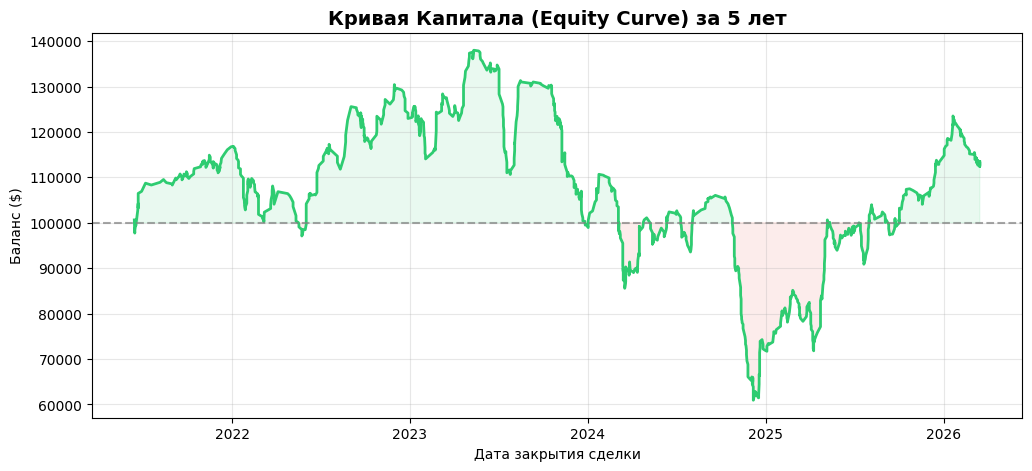

In [12]:
# ==============================================================================
# 🌌 FSD Engine (Phase 10): 5-YEAR PORTFOLIO SIMULATOR
# Симуляция капитала: $100,000 | Риск на сделку: $10,000 | Учет SL и TP
# ==============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from tqdm.notebook import tqdm
from IPython.display import display, HTML
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

class PortfolioBacktester:
    def __init__(self, tickers_f: list, tickers_a: list, initial_capital=100000, trade_size=10000):
        self.tickers_f = list(set(tickers_f)) # Гиганты (только LONG)
        self.tickers_a = list(set(tickers_a)) # Мемы/Крипта (только SHORT)
        self.all_tickers = self.tickers_f + self.tickers_a
        self.initial_capital = initial_capital
        self.trade_size = trade_size
        self.trades = []
        
    def run_simulation(self, years=5):
        days = years * 252
        display(HTML(f"<p style='color:#3498db; font-weight:bold;'>[*] Машина Времени: Загрузка {years} лет истории для {len(self.all_tickers)} активов...</p>"))
        
        try:
            data = yf.download(self.all_tickers, period=f"{days}d", progress=False)
        except Exception as e:
            display(HTML(f"<p style='color:#e74c3c;'>[!] Ошибка API: {e}</p>"))
            return

        for ticker in tqdm(self.all_tickers, desc="Симуляция торгов (SL/TP)"):
            if isinstance(data.columns, pd.MultiIndex):
                if ticker in data.columns.get_level_values(1): df = data.xs(ticker, axis=1, level=1)
                elif ticker in data.columns.get_level_values(0): df = data[ticker]
                else: continue
            else: df = data

            df = df.dropna().copy()
            if len(df) < 60: continue

            # Расчет физики
            df['Vol_USD'] = df['Close'] * df['Volume']
            roll_std = df['Vol_USD'].rolling(60).std().replace(0, 1e-9)
            z_scores = (df['Vol_USD'] - df['Vol_USD'].rolling(60).mean()) / roll_std
            df['P_Vol'] = 1 / (1 + np.exp(-z_scores * 1.5))
            
            sma20 = df['Close'].rolling(20).mean()
            std20 = df['Close'].rolling(20).std()
            lower_bb, upper_bb = sma20 - (std20 * 2), sma20 + (std20 * 2)
            df['Percent_B'] = (df['Close'] - lower_bb) / (upper_bb - lower_bb).replace(0, 1e-9)
            
            hl, hc, lc = df['High'] - df['Low'], np.abs(df['High'] - df['Close'].shift()), np.abs(df['Low'] - df['Close'].shift())
            df['ATR'] = pd.concat([hl, hc, lc], axis=1).max(axis=1).rolling(14).mean()
            
            df['Delta_1d'] = df['Close'].diff()
            df['Vector_1'] = np.select([df['Delta_1d'] >= df['ATR']/2, df['Delta_1d'] <= -df['ATR']/2], [1, -1], default=0)
            
            # Разделяем логику на LONG (для F) и SHORT (для A)
            if ticker in self.tickers_f:
                df['Vector_2'] = np.where(df['Close'].diff(3) > 0, 1, -1)
                signals = df[(df['P_Vol'] >= 0.65) & (df['Vector_1'] == 0) & (df['Vector_2'] == -1) & (df['Percent_B'] <= 0.15)]
                trade_type = 'LONG'
            else:
                df['Vector_2'] = np.where(df['Close'].diff(3) > 0, 1, -1) # Ищем рост для шорта
                signals = df[(df['P_Vol'] >= 0.65) & (df['Vector_1'] == 0) & (df['Vector_2'] == 1) & (df['Percent_B'] >= 0.85)]
                trade_type = 'SHORT'

            # Симулятор сделок
            for idx, row in signals.iterrows():
                loc = df.index.get_loc(idx)
                if loc + 1 >= len(df): continue # Сигнал в последний день истории
                
                entry_price = row['Close']
                atr = row['ATR']
                
                if trade_type == 'LONG':
                    sl, tp = entry_price - (1.5 * atr), entry_price + (3.0 * atr)
                else:
                    sl, tp = entry_price + (1.5 * atr), entry_price - (3.0 * atr)

                # Смотрим в будущее (макс 20 дней)
                exit_price = None
                exit_date = None
                exit_reason = "Time Stop (20d)"
                
                for i in range(1, 21):
                    if loc + i >= len(df): break
                    future_day = df.iloc[loc + i]
                    
                    if trade_type == 'LONG':
                        if future_day['Low'] <= sl:
                            exit_price, exit_date, exit_reason = sl, df.index[loc + i], "Stop Loss"
                            break
                        elif future_day['High'] >= tp:
                            exit_price, exit_date, exit_reason = tp, df.index[loc + i], "Take Profit"
                            break
                    else: # SHORT
                        if future_day['High'] >= sl:
                            exit_price, exit_date, exit_reason = sl, df.index[loc + i], "Stop Loss"
                            break
                        elif future_day['Low'] <= tp:
                            exit_price, exit_date, exit_reason = tp, df.index[loc + i], "Take Profit"
                            break
                            
                # Если ни SL, ни TP не сработали, закрываем по рынку на 20-й день
                if exit_price is None:
                    exit_idx = min(loc + 20, len(df) - 1)
                    exit_price = df.iloc[exit_idx]['Close']
                    exit_date = df.index[exit_idx]
                    
                # Финансовый результат (с учетом 0.1% комиссии за сделку)
                commission = self.trade_size * 0.001
                if trade_type == 'LONG':
                    pnl = (self.trade_size / entry_price) * (exit_price - entry_price) - commission
                else:
                    pnl = (self.trade_size / entry_price) * (entry_price - exit_price) - commission
                    
                self.trades.append({
                    "Date": exit_date, "Entry_Date": idx, "Ticker": ticker, "Type": trade_type,
                    "Entry": entry_price, "Exit": exit_price, "Reason": exit_reason, "PnL": pnl
                })

    def analyze_equity(self):
        trades_df = pd.DataFrame(self.trades)
        if trades_df.empty:
            display(HTML("<h3>Сделок не найдено.</h3>"))
            return
            
        # Сортируем сделки по дате закрытия для построения кривой капитала
        trades_df = trades_df.sort_values(by="Date").reset_index(drop=True)
        trades_df['Cumulative_PnL'] = trades_df['PnL'].cumsum()
        trades_df['Equity'] = self.initial_capital + trades_df['Cumulative_PnL']
        
        final_equity = trades_df['Equity'].iloc[-1]
        total_trades = len(trades_df)
        win_trades = len(trades_df[trades_df['PnL'] > 0])
        win_rate = (win_trades / total_trades) * 100
        roi = ((final_equity - self.initial_capital) / self.initial_capital) * 100
        
        display(HTML(f"<h2>📊 ОТЧЕТ БЭКТЕСТЕРА (5 ЛЕТ): Стартовый капитал ${self.initial_capital:,.0f}</h2>"))
        
        html = f"""
        <table style='width:100%; text-align:center; border-collapse: collapse; font-family: sans-serif; font-size: 16px;'>
            <tr style='background:#2c3e50; color:white;'>
                <th style='padding:15px;'>Всего Сделок</th>
                <th style='padding:15px;'>WinRate (Точность)</th>
                <th style='padding:15px;'>Чистая Прибыль ($)</th>
                <th style='padding:15px;'>Итоговый Баланс</th>
                <th style='padding:15px;'>ROI (Доходность)</th>
            </tr>
            <tr>
                <td style='padding:15px; border-bottom: 1px solid #ddd;'><b>{total_trades}</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:{'#2ecc71' if win_rate > 50 else '#e74c3c'}'><b>{win_rate:.1f}%</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:{'#2ecc71' if final_equity > self.initial_capital else '#e74c3c'}'><b>${(final_equity - self.initial_capital):,.2f}</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd;'><b>${final_equity:,.2f}</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:{'#2ecc71' if roi > 0 else '#e74c3c'}'><b>{roi:.2f}%</b></td>
            </tr>
        </table>
        """
        display(HTML(html))

        # Детализация по типам выхода
        tp_hits = len(trades_df[trades_df['Reason'] == 'Take Profit'])
        sl_hits = len(trades_df[trades_df['Reason'] == 'Stop Loss'])
        ts_hits = len(trades_df[trades_df['Reason'] == 'Time Stop (20d)'])
        
        display(HTML(f"<p><b>Разбор сделок:</b> Сработал Take-Profit: {tp_hits} | Сработал Stop-Loss: {sl_hits} | Выход по времени (20 дней): {ts_hits}</p>"))

        # Отрисовка Кривой Капитала (Equity Curve)
        plt.figure(figsize=(12, 5))
        plt.plot(trades_df['Date'], trades_df['Equity'], color='#2ecc71' if roi > 0 else '#e74c3c', linewidth=2)
        plt.axhline(y=self.initial_capital, color='grey', linestyle='--', alpha=0.7)
        plt.title('Кривая Капитала (Equity Curve) за 5 лет', fontsize=14, fontweight='bold')
        plt.xlabel('Дата закрытия сделки')
        plt.ylabel('Баланс ($)')
        plt.grid(alpha=0.3)
        plt.fill_between(trades_df['Date'], trades_df['Equity'], self.initial_capital, where=(trades_df['Equity'] > self.initial_capital), color='#2ecc71', alpha=0.1)
        plt.fill_between(trades_df['Date'], trades_df['Equity'], self.initial_capital, where=(trades_df['Equity'] <= self.initial_capital), color='#e74c3c', alpha=0.1)
        plt.show()

# ==============================================================================
# ЗАПУСК ЭМУЛЯТОРА
# ==============================================================================
# Выборка ТОП-30 Гигантов для LONG (включая тех, что нашли на скрине)
F_TICKERS = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA", "JPM", "V", "JNJ", "WMT", "PG", "MA", "HD", "CVX", "MRK", "ABBV", "PEP", "KO", "BAC", "TMO", "COST", "CSCO", "MCD", "CRM", "DIS", "QCOM", "BLK", "ADI", "DHR"]

# Выборка Мусора/Крипты для SHORT
A_TICKERS = ["BTC-USD", "ETH-USD", "SOL-USD", "DOGE-USD", "GME", "AMC", "CVNA", "DJT", "MSTR", "HOOD", "COIN", "RIVN"]

backtester = PortfolioBacktester(tickers_f=F_TICKERS, tickers_a=A_TICKERS, initial_capital=100000, trade_size=10000)
backtester.run_simulation(years=5)
backtester.analyze_equity()

Симуляция с Макро-Фильтром:   0%|          | 0/42 [00:00<?, ?it/s]

Всего Сделок,WinRate (Точность),Чистая Прибыль ($),Итоговый Баланс,ROI (Доходность)
546 (Фильтр отсек лишнее),44.9%,"$40,729.91","$140,729.91",40.73%


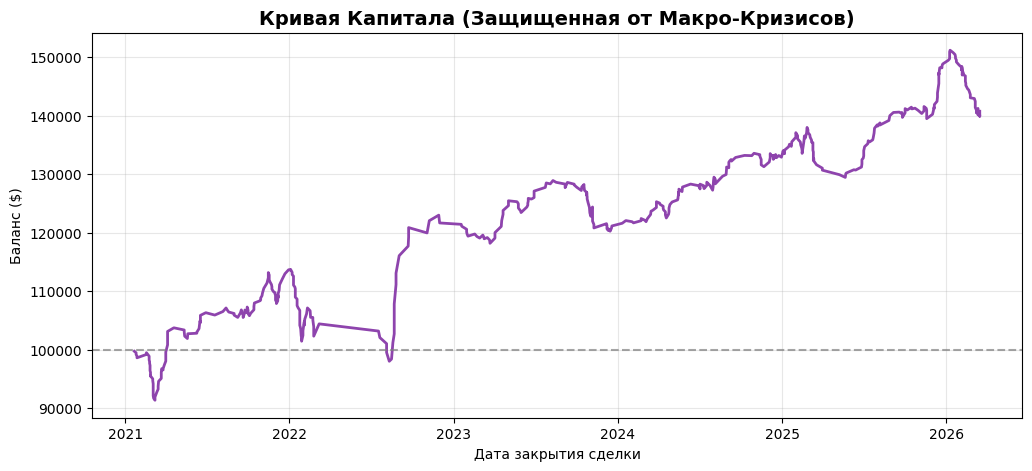

In [13]:
# ==============================================================================
# 🌌 FSD Engine (Phase 11): MACRO-REGIME BACKTESTER (SPY SMA 200)
# Добавлен фильтр глобального тренда для защиты от макроэкономических обвалов
# ==============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from tqdm.notebook import tqdm
from IPython.display import display, HTML
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

class RegimeBacktester:
    def __init__(self, tickers_f: list, tickers_a: list, initial_capital=100000, trade_size=10000):
        self.tickers_f = list(set(tickers_f)) # Гиганты (LONG)
        self.tickers_a = list(set(tickers_a)) # Мемы/Крипта (SHORT)
        self.all_tickers = self.tickers_f + self.tickers_a
        self.initial_capital = initial_capital
        self.trade_size = trade_size
        self.trades = []
        
    def run_simulation(self, years=5):
        # Добавляем 300 дней запаса для корректного расчета SMA 200 на старте теста
        fetch_days = (years * 252) + 300 
        
        display(HTML(f"<p style='color:#3498db; font-weight:bold;'>[*] Подключение Макро-Фильтра (SPY). Загрузка истории...</p>"))
        
        try:
            # Скачиваем индекс SPY отдельно для чистоты данных
            spy_data = yf.download("SPY", period=f"{fetch_days}d", progress=False)['Close']
            if isinstance(spy_data, pd.DataFrame): 
                spy_data = spy_data.squeeze()
            
            # Рассчитываем 200-дневную скользящую для S&P 500
            spy_sma200 = spy_data.rolling(200).mean()
            
            # Скачиваем все остальные активы
            data = yf.download(self.all_tickers, period=f"{fetch_days}d", progress=False)
        except Exception as e:
            display(HTML(f"<p style='color:#e74c3c;'>[!] Ошибка API: {e}</p>"))
            return

        for ticker in tqdm(self.all_tickers, desc="Симуляция с Макро-Фильтром"):
            if isinstance(data.columns, pd.MultiIndex):
                if ticker in data.columns.get_level_values(1): df = data.xs(ticker, axis=1, level=1)
                elif ticker in data.columns.get_level_values(0): df = data[ticker]
                else: continue
            else: df = data

            df = df.dropna().copy()
            if len(df) < 250: continue # Нужна длинная история

            # Приклеиваем макро-данные к текущему активу
            df['SPY_Close'] = spy_data
            df['SPY_SMA200'] = spy_sma200
            df = df.dropna(subset=['SPY_SMA200']) # Отрезаем стартовые пустые дни

            # Расчет физики актива
            df['Vol_USD'] = df['Close'] * df['Volume']
            roll_std = df['Vol_USD'].rolling(60).std().replace(0, 1e-9)
            z_scores = (df['Vol_USD'] - df['Vol_USD'].rolling(60).mean()) / roll_std
            df['P_Vol'] = 1 / (1 + np.exp(-z_scores * 1.5))
            
            sma20 = df['Close'].rolling(20).mean()
            std20 = df['Close'].rolling(20).std()
            lower_bb, upper_bb = sma20 - (std20 * 2), sma20 + (std20 * 2)
            df['Percent_B'] = (df['Close'] - lower_bb) / (upper_bb - lower_bb).replace(0, 1e-9)
            
            hl, hc, lc = df['High'] - df['Low'], np.abs(df['High'] - df['Close'].shift()), np.abs(df['Low'] - df['Close'].shift())
            df['ATR'] = pd.concat([hl, hc, lc], axis=1).max(axis=1).rolling(14).mean()
            
            df['Delta_1d'] = df['Close'].diff()
            df['Vector_1'] = np.select([df['Delta_1d'] >= df['ATR']/2, df['Delta_1d'] <= -df['ATR']/2], [1, -1], default=0)
            
            # РЕЖИМНЫЙ ФИЛЬТР (The Regime Filter)
            is_bull_market = df['SPY_Close'] > df['SPY_SMA200']
            
            if ticker in self.tickers_f:
                df['Vector_2'] = np.where(df['Close'].diff(3) > 0, 1, -1)
                # LONG: Разрешен ТОЛЬКО если S&P 500 выше SMA 200 (Бычий рынок)
                signals = df[(df['P_Vol'] >= 0.65) & (df['Vector_1'] == 0) & (df['Vector_2'] == -1) & (df['Percent_B'] <= 0.15) & (is_bull_market)]
                trade_type = 'LONG'
            else:
                df['Vector_2'] = np.where(df['Close'].diff(3) > 0, 1, -1)
                # SHORT: Разрешен ТОЛЬКО если S&P 500 ниже SMA 200 (Медвежий рынок / Паника)
                signals = df[(df['P_Vol'] >= 0.65) & (df['Vector_1'] == 0) & (df['Vector_2'] == 1) & (df['Percent_B'] >= 0.85) & (~is_bull_market)]
                trade_type = 'SHORT'

            # Симулятор сделок (SL и TP)
            for idx, row in signals.iterrows():
                loc = df.index.get_loc(idx)
                if loc + 1 >= len(df): continue 
                
                entry_price, atr = row['Close'], row['ATR']
                sl = entry_price - (1.5 * atr) if trade_type == 'LONG' else entry_price + (1.5 * atr)
                tp = entry_price + (3.0 * atr) if trade_type == 'LONG' else entry_price - (3.0 * atr)

                exit_price, exit_date, exit_reason = None, None, "Time Stop (20d)"
                
                for i in range(1, 21):
                    if loc + i >= len(df): break
                    future_day = df.iloc[loc + i]
                    
                    if trade_type == 'LONG':
                        if future_day['Low'] <= sl: exit_price, exit_date, exit_reason = sl, df.index[loc + i], "Stop Loss"; break
                        elif future_day['High'] >= tp: exit_price, exit_date, exit_reason = tp, df.index[loc + i], "Take Profit"; break
                    else:
                        if future_day['High'] >= sl: exit_price, exit_date, exit_reason = sl, df.index[loc + i], "Stop Loss"; break
                        elif future_day['Low'] <= tp: exit_price, exit_date, exit_reason = tp, df.index[loc + i], "Take Profit"; break
                            
                if exit_price is None:
                    exit_idx = min(loc + 20, len(df) - 1)
                    exit_price, exit_date = df.iloc[exit_idx]['Close'], df.index[exit_idx]
                    
                commission = self.trade_size * 0.001
                pnl = (self.trade_size / entry_price) * (exit_price - entry_price) - commission if trade_type == 'LONG' else (self.trade_size / entry_price) * (entry_price - exit_price) - commission
                    
                self.trades.append({"Date": exit_date, "Type": trade_type, "PnL": pnl, "Reason": exit_reason})

    def analyze_equity(self):
        trades_df = pd.DataFrame(self.trades)
        if trades_df.empty:
            display(HTML("<h3>Сделок не найдено. Фильтр отсек весь шум.</h3>"))
            return
            
        trades_df = trades_df.sort_values(by="Date").reset_index(drop=True)
        trades_df['Equity'] = self.initial_capital + trades_df['PnL'].cumsum()
        
        final_equity = trades_df['Equity'].iloc[-1]
        total_trades = len(trades_df)
        win_rate = (len(trades_df[trades_df['PnL'] > 0]) / total_trades) * 100
        roi = ((final_equity - self.initial_capital) / self.initial_capital) * 100
        
        display(HTML(f"<h2>🛡️ ОТЧЕТ: МАКРО-ФИЛЬТР (SMA 200) | Стартовый капитал ${self.initial_capital:,.0f}</h2>"))
        
        html = f"""
        <table style='width:100%; text-align:center; border-collapse: collapse; font-family: sans-serif; font-size: 16px;'>
            <tr style='background:#8e44ad; color:white;'>
                <th style='padding:15px;'>Всего Сделок</th>
                <th style='padding:15px;'>WinRate (Точность)</th>
                <th style='padding:15px;'>Чистая Прибыль ($)</th>
                <th style='padding:15px;'>Итоговый Баланс</th>
                <th style='padding:15px;'>ROI (Доходность)</th>
            </tr>
            <tr>
                <td style='padding:15px; border-bottom: 1px solid #ddd;'><b>{total_trades}</b> (Фильтр отсек лишнее)</td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:{'#2ecc71' if win_rate > 40 else '#e74c3c'}'><b>{win_rate:.1f}%</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:{'#2ecc71' if final_equity > self.initial_capital else '#e74c3c'}'><b>${(final_equity - self.initial_capital):,.2f}</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd;'><b>${final_equity:,.2f}</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:{'#2ecc71' if roi > 0 else '#e74c3c'}'><b>{roi:.2f}%</b></td>
            </tr>
        </table>
        """
        display(HTML(html))

        # Отрисовка Кривой Капитала
        plt.figure(figsize=(12, 5))
        plt.plot(trades_df['Date'], trades_df['Equity'], color='#8e44ad', linewidth=2)
        plt.axhline(y=self.initial_capital, color='grey', linestyle='--', alpha=0.7)
        plt.title('Кривая Капитала (Защищенная от Макро-Кризисов)', fontsize=14, fontweight='bold')
        plt.xlabel('Дата закрытия сделки')
        plt.ylabel('Баланс ($)')
        plt.grid(alpha=0.3)
        plt.show()

# ==============================================================================
# ЗАПУСК ЭМУЛЯТОРА
# ==============================================================================
F_TICKERS = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA", "JPM", "V", "JNJ", "WMT", "PG", "MA", "HD", "CVX", "MRK", "ABBV", "PEP", "KO", "BAC", "TMO", "COST", "CSCO", "MCD", "CRM", "DIS", "QCOM", "BLK", "ADI", "DHR"]
A_TICKERS = ["BTC-USD", "ETH-USD", "SOL-USD", "DOGE-USD", "GME", "AMC", "CVNA", "DJT", "MSTR", "HOOD", "COIN", "RIVN"]

backtester = RegimeBacktester(tickers_f=F_TICKERS, tickers_a=A_TICKERS)
backtester.run_simulation(years=5)
backtester.analyze_equity()

Симуляция с плечом 2x:   0%|          | 0/42 [00:00<?, ?it/s]

WinRate (Точность),Чистая Прибыль ($),Итоговый Баланс,ROI (Доходность),Max Просадка
44.9%,"$81,620.42","$181,620.42",81.62%,-24.58%


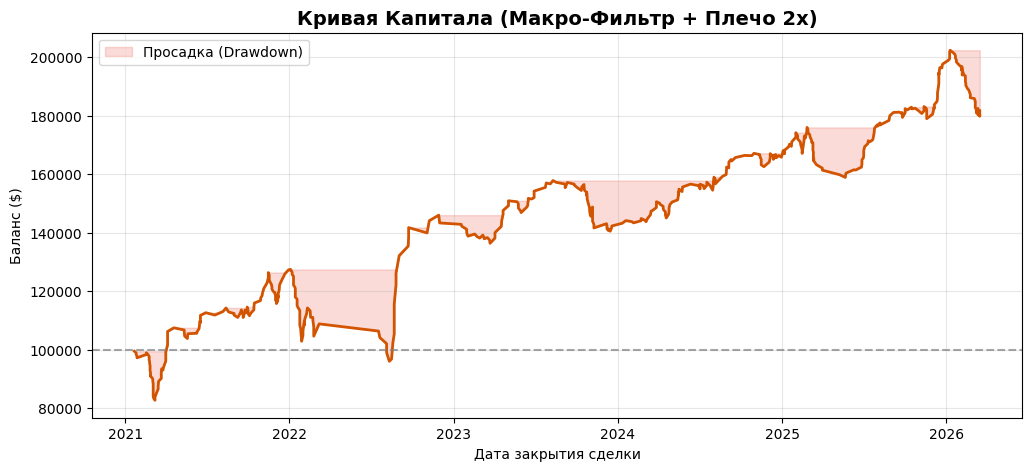

In [14]:
# ==============================================================================
# 🌌 FSD Engine (Phase 12): LEVERAGED MACRO-BACKTESTER (2x Margin)
# Макро-фильтр (SPY SMA 200) + Кредитное плечо x2 + Расчет просадки
# ==============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from tqdm.notebook import tqdm
from IPython.display import display, HTML
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

class LeveragedBacktester:
    def __init__(self, tickers_f: list, tickers_a: list, initial_capital=100000, trade_size=10000, leverage=2):
        self.tickers_f = list(set(tickers_f)) 
        self.tickers_a = list(set(tickers_a)) 
        self.all_tickers = self.tickers_f + self.tickers_a
        self.initial_capital = initial_capital
        self.trade_size = trade_size
        self.leverage = leverage # КРЕДИТНОЕ ПЛЕЧО
        self.trades = []
        
    def run_simulation(self, years=5):
        fetch_days = (years * 252) + 300 
        
        display(HTML(f"<p style='color:#e67e22; font-weight:bold;'>[*] Турбо-режим: Включено кредитное плечо {self.leverage}x. Загрузка данных...</p>"))
        
        try:
            spy_data = yf.download("SPY", period=f"{fetch_days}d", progress=False)['Close']
            if isinstance(spy_data, pd.DataFrame): spy_data = spy_data.squeeze()
            spy_sma200 = spy_data.rolling(200).mean()
            
            data = yf.download(self.all_tickers, period=f"{fetch_days}d", progress=False)
        except Exception as e:
            display(HTML(f"<p style='color:#e74c3c;'>[!] Ошибка API: {e}</p>"))
            return

        for ticker in tqdm(self.all_tickers, desc=f"Симуляция с плечом {self.leverage}x"):
            if isinstance(data.columns, pd.MultiIndex):
                if ticker in data.columns.get_level_values(1): df = data.xs(ticker, axis=1, level=1)
                elif ticker in data.columns.get_level_values(0): df = data[ticker]
                else: continue
            else: df = data

            df = df.dropna().copy()
            if len(df) < 250: continue

            df['SPY_Close'] = spy_data
            df['SPY_SMA200'] = spy_sma200
            df = df.dropna(subset=['SPY_SMA200'])

            # Физика
            df['Vol_USD'] = df['Close'] * df['Volume']
            roll_std = df['Vol_USD'].rolling(60).std().replace(0, 1e-9)
            z_scores = (df['Vol_USD'] - df['Vol_USD'].rolling(60).mean()) / roll_std
            df['P_Vol'] = 1 / (1 + np.exp(-z_scores * 1.5))
            
            sma20 = df['Close'].rolling(20).mean()
            std20 = df['Close'].rolling(20).std()
            lower_bb, upper_bb = sma20 - (std20 * 2), sma20 + (std20 * 2)
            df['Percent_B'] = (df['Close'] - lower_bb) / (upper_bb - lower_bb).replace(0, 1e-9)
            
            hl, hc, lc = df['High'] - df['Low'], np.abs(df['High'] - df['Close'].shift()), np.abs(df['Low'] - df['Close'].shift())
            df['ATR'] = pd.concat([hl, hc, lc], axis=1).max(axis=1).rolling(14).mean()
            
            df['Delta_1d'] = df['Close'].diff()
            df['Vector_1'] = np.select([df['Delta_1d'] >= df['ATR']/2, df['Delta_1d'] <= -df['ATR']/2], [1, -1], default=0)
            
            # Макро-фильтр
            is_bull_market = df['SPY_Close'] > df['SPY_SMA200']
            
            if ticker in self.tickers_f:
                df['Vector_2'] = np.where(df['Close'].diff(3) > 0, 1, -1)
                signals = df[(df['P_Vol'] >= 0.65) & (df['Vector_1'] == 0) & (df['Vector_2'] == -1) & (df['Percent_B'] <= 0.15) & (is_bull_market)]
                trade_type = 'LONG'
            else:
                df['Vector_2'] = np.where(df['Close'].diff(3) > 0, 1, -1)
                signals = df[(df['P_Vol'] >= 0.65) & (df['Vector_1'] == 0) & (df['Vector_2'] == 1) & (df['Percent_B'] >= 0.85) & (~is_bull_market)]
                trade_type = 'SHORT'

            for idx, row in signals.iterrows():
                loc = df.index.get_loc(idx)
                if loc + 1 >= len(df): continue 
                
                entry_price, atr = row['Close'], row['ATR']
                sl = entry_price - (1.5 * atr) if trade_type == 'LONG' else entry_price + (1.5 * atr)
                tp = entry_price + (3.0 * atr) if trade_type == 'LONG' else entry_price - (3.0 * atr)

                exit_price, exit_date, exit_reason = None, None, "Time Stop (20d)"
                
                for i in range(1, 21):
                    if loc + i >= len(df): break
                    future_day = df.iloc[loc + i]
                    
                    if trade_type == 'LONG':
                        if future_day['Low'] <= sl: exit_price, exit_date, exit_reason = sl, df.index[loc + i], "Stop Loss"; break
                        elif future_day['High'] >= tp: exit_price, exit_date, exit_reason = tp, df.index[loc + i], "Take Profit"; break
                    else:
                        if future_day['High'] >= sl: exit_price, exit_date, exit_reason = sl, df.index[loc + i], "Stop Loss"; break
                        elif future_day['Low'] <= tp: exit_price, exit_date, exit_reason = tp, df.index[loc + i], "Take Profit"; break
                            
                if exit_price is None:
                    exit_idx = min(loc + 20, len(df) - 1)
                    exit_price, exit_date = df.iloc[exit_idx]['Close'], df.index[exit_idx]
                    
                # РАСЧЕТ ПРИБЫЛИ С УЧЕТОМ ПЛЕЧА
                position_size = self.trade_size * self.leverage
                commission = position_size * 0.001 # Комиссия берется с полного объема позиции
                
                if trade_type == 'LONG':
                    pnl = (position_size / entry_price) * (exit_price - entry_price) - commission
                else:
                    pnl = (position_size / entry_price) * (entry_price - exit_price) - commission
                    
                self.trades.append({"Date": exit_date, "Type": trade_type, "PnL": pnl, "Reason": exit_reason})

    def analyze_equity(self):
        trades_df = pd.DataFrame(self.trades)
        if trades_df.empty:
            display(HTML("<h3>Сделок не найдено. Фильтр отсек весь шум.</h3>"))
            return
            
        trades_df = trades_df.sort_values(by="Date").reset_index(drop=True)
        trades_df['Equity'] = self.initial_capital + trades_df['PnL'].cumsum()
        
        # Расчет Максимальной Просадки (Max Drawdown)
        trades_df['Running_Max'] = trades_df['Equity'].cummax()
        trades_df['Drawdown'] = (trades_df['Equity'] - trades_df['Running_Max']) / trades_df['Running_Max'] * 100
        max_drawdown = trades_df['Drawdown'].min()
        
        final_equity = trades_df['Equity'].iloc[-1]
        total_trades = len(trades_df)
        win_rate = (len(trades_df[trades_df['PnL'] > 0]) / total_trades) * 100
        roi = ((final_equity - self.initial_capital) / self.initial_capital) * 100
        
        display(HTML(f"<h2>🔥 ОТЧЕТ: ТОРГОВЛЯ С ПЛЕЧОМ {self.leverage}X | Стартовый капитал ${self.initial_capital:,.0f}</h2>"))
        
        html = f"""
        <table style='width:100%; text-align:center; border-collapse: collapse; font-family: sans-serif; font-size: 16px;'>
            <tr style='background:#d35400; color:white;'>
                <th style='padding:15px;'>WinRate (Точность)</th>
                <th style='padding:15px;'>Чистая Прибыль ($)</th>
                <th style='padding:15px;'>Итоговый Баланс</th>
                <th style='padding:15px;'>ROI (Доходность)</th>
                <th style='padding:15px;'>Max Просадка</th>
            </tr>
            <tr>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:{'#2ecc71' if win_rate > 40 else '#e74c3c'}'><b>{win_rate:.1f}%</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:{'#2ecc71' if final_equity > self.initial_capital else '#e74c3c'}'><b>${(final_equity - self.initial_capital):,.2f}</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd;'><b>${final_equity:,.2f}</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:{'#2ecc71' if roi > 0 else '#e74c3c'}'><b>{roi:.2f}%</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:#e74c3c;'><b>{max_drawdown:.2f}%</b></td>
            </tr>
        </table>
        """
        display(HTML(html))

        # Отрисовка Кривой Капитала
        plt.figure(figsize=(12, 5))
        plt.plot(trades_df['Date'], trades_df['Equity'], color='#d35400', linewidth=2)
        plt.axhline(y=self.initial_capital, color='grey', linestyle='--', alpha=0.7)
        plt.title(f'Кривая Капитала (Макро-Фильтр + Плечо {self.leverage}x)', fontsize=14, fontweight='bold')
        plt.xlabel('Дата закрытия сделки')
        plt.ylabel('Баланс ($)')
        plt.grid(alpha=0.3)
        plt.fill_between(trades_df['Date'], trades_df['Equity'], trades_df['Running_Max'], color='#e74c3c', alpha=0.2, label='Просадка (Drawdown)')
        plt.legend()
        plt.show()

# ==============================================================================
# ЗАПУСК ЭМУЛЯТОРА С ПЛЕЧОМ
# ==============================================================================
F_TICKERS = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA", "JPM", "V", "JNJ", "WMT", "PG", "MA", "HD", "CVX", "MRK", "ABBV", "PEP", "KO", "BAC", "TMO", "COST", "CSCO", "MCD", "CRM", "DIS", "QCOM", "BLK", "ADI", "DHR"]
A_TICKERS = ["BTC-USD", "ETH-USD", "SOL-USD", "DOGE-USD", "GME", "AMC", "CVNA", "DJT", "MSTR", "HOOD", "COIN", "RIVN"]

# leverage=2 умножает прибыль и убытки на 2
backtester_lev = LeveragedBacktester(tickers_f=F_TICKERS, tickers_a=A_TICKERS, initial_capital=100000, trade_size=10000, leverage=2)
backtester_lev.run_simulation(years=5)
backtester_lev.analyze_equity()

Анализ столетия:   0%|          | 0/42 [00:00<?, ?it/s]

Всего Сделок,WinRate,Чистая Прибыль ($),Итоговый Баланс,ROI,Max Просадка
3190,45.5%,"$479,366.69","$579,366.69",479.37%,-19.74%


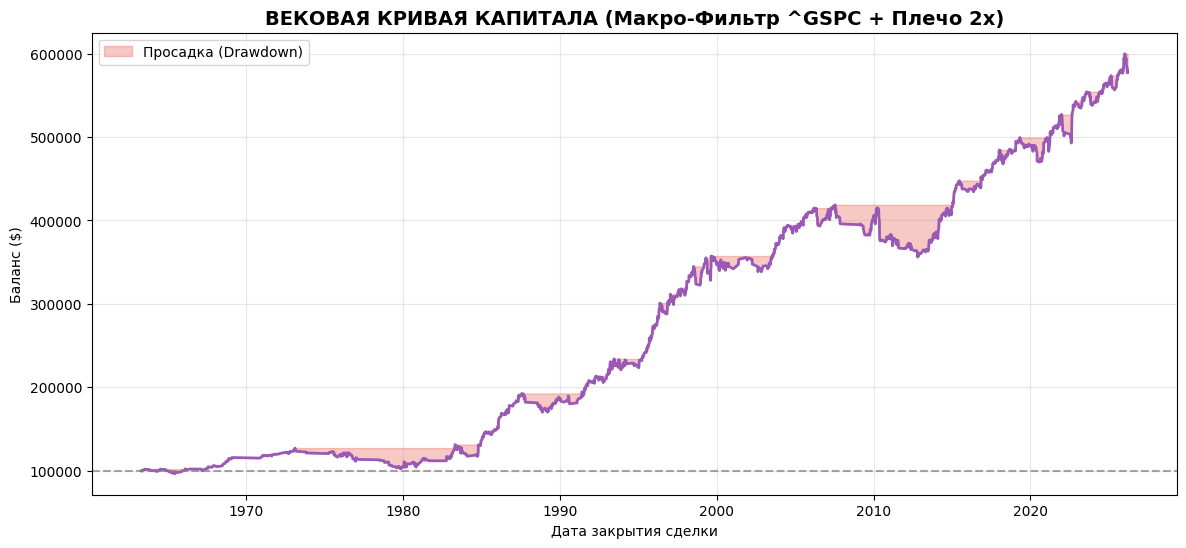

In [16]:
# ==============================================================================
# 🌌 FSD Engine (Phase 13): CENTENNIAL BACKTESTER (50-100 Years)
# Глубокий исторический прогон | Макро-фильтр (^GSPC) | Плечо 2x
# ==============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from tqdm.notebook import tqdm
from IPython.display import display, HTML
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

class CentennialBacktester:
    def __init__(self, tickers_f: list, tickers_a: list, initial_capital=100000, trade_size=10000, leverage=2):
        self.tickers_f = list(set(tickers_f)) 
        self.tickers_a = list(set(tickers_a)) 
        self.all_tickers = self.tickers_f + self.tickers_a
        self.initial_capital = initial_capital
        self.trade_size = trade_size
        self.leverage = leverage
        self.trades = []
        
    def run_simulation(self):
        display(HTML(f"<p style='color:#8e44ad; font-weight:bold;'>[*] Эпохальный тест: Загрузка всей доступной истории (до 100 лет). Это займет время...</p>"))
        
        try:
            # ИСПОЛЬЗУЕМ ^GSPC (Сам индекс S&P 500), так как SPY существует только с 1993 года
            macro_data = yf.download("^GSPC", period="max", progress=False)['Close']
            if isinstance(macro_data, pd.DataFrame): macro_data = macro_data.squeeze()
            macro_sma200 = macro_data.rolling(200).mean()
            
            # Загружаем всю историю по нашим активам
            data = yf.download(self.all_tickers, period="max", progress=False)
        except Exception as e:
            display(HTML(f"<p style='color:#e74c3c;'>[!] Ошибка API: {e}</p>"))
            return

        # ИСПРАВЛЕНО: Убрал {ticker} из описания tqdm
        for ticker in tqdm(self.all_tickers, desc="Анализ столетия"):
            if isinstance(data.columns, pd.MultiIndex):
                if ticker in data.columns.get_level_values(1): df = data.xs(ticker, axis=1, level=1)
                elif ticker in data.columns.get_level_values(0): df = data[ticker]
                else: continue
            else: df = data

            df = df.dropna().copy()
            if len(df) < 250: continue # Пропускаем слишком молодые активы

            # Выравниваем даты индекса и актива
            df['Macro_Close'] = macro_data
            df['Macro_SMA200'] = macro_sma200
            df = df.dropna(subset=['Macro_SMA200'])

            # Физика
            df['Vol_USD'] = df['Close'] * df['Volume']
            roll_std = df['Vol_USD'].rolling(60).std().replace(0, 1e-9)
            z_scores = (df['Vol_USD'] - df['Vol_USD'].rolling(60).mean()) / roll_std
            df['P_Vol'] = 1 / (1 + np.exp(-z_scores * 1.5))
            
            sma20 = df['Close'].rolling(20).mean()
            std20 = df['Close'].rolling(20).std()
            lower_bb, upper_bb = sma20 - (std20 * 2), sma20 + (std20 * 2)
            df['Percent_B'] = (df['Close'] - lower_bb) / (upper_bb - lower_bb).replace(0, 1e-9)
            
            hl, hc, lc = df['High'] - df['Low'], np.abs(df['High'] - df['Close'].shift()), np.abs(df['Low'] - df['Close'].shift())
            df['ATR'] = pd.concat([hl, hc, lc], axis=1).max(axis=1).rolling(14).mean()
            
            df['Delta_1d'] = df['Close'].diff()
            df['Vector_1'] = np.select([df['Delta_1d'] >= df['ATR']/2, df['Delta_1d'] <= -df['ATR']/2], [1, -1], default=0)
            
            # Макро-фильтр по самому индексу S&P 500
            is_bull_market = df['Macro_Close'] > df['Macro_SMA200']
            
            if ticker in self.tickers_f:
                df['Vector_2'] = np.where(df['Close'].diff(3) > 0, 1, -1)
                signals = df[(df['P_Vol'] >= 0.65) & (df['Vector_1'] == 0) & (df['Vector_2'] == -1) & (df['Percent_B'] <= 0.15) & (is_bull_market)]
                trade_type = 'LONG'
            else:
                df['Vector_2'] = np.where(df['Close'].diff(3) > 0, 1, -1)
                signals = df[(df['P_Vol'] >= 0.65) & (df['Vector_1'] == 0) & (df['Vector_2'] == 1) & (df['Percent_B'] >= 0.85) & (~is_bull_market)]
                trade_type = 'SHORT'

            for idx, row in signals.iterrows():
                loc = df.index.get_loc(idx)
                if loc + 1 >= len(df): continue 
                
                entry_price, atr = row['Close'], row['ATR']
                sl = entry_price - (1.5 * atr) if trade_type == 'LONG' else entry_price + (1.5 * atr)
                tp = entry_price + (3.0 * atr) if trade_type == 'LONG' else entry_price - (3.0 * atr)

                exit_price, exit_date, exit_reason = None, None, "Time Stop (20d)"
                
                for i in range(1, 21):
                    if loc + i >= len(df): break
                    future_day = df.iloc[loc + i]
                    
                    if trade_type == 'LONG':
                        if future_day['Low'] <= sl: exit_price, exit_date, exit_reason = sl, df.index[loc + i], "Stop Loss"; break
                        elif future_day['High'] >= tp: exit_price, exit_date, exit_reason = tp, df.index[loc + i], "Take Profit"; break
                    else:
                        if future_day['High'] >= sl: exit_price, exit_date, exit_reason = sl, df.index[loc + i], "Stop Loss"; break
                        elif future_day['Low'] <= tp: exit_price, exit_date, exit_reason = tp, df.index[loc + i], "Take Profit"; break
                            
                if exit_price is None:
                    exit_idx = min(loc + 20, len(df) - 1)
                    exit_price, exit_date = df.iloc[exit_idx]['Close'], df.index[exit_idx]
                    
                position_size = self.trade_size * self.leverage
                commission = position_size * 0.001 
                
                if trade_type == 'LONG':
                    pnl = (position_size / entry_price) * (exit_price - entry_price) - commission
                else:
                    pnl = (position_size / entry_price) * (entry_price - exit_price) - commission
                    
                self.trades.append({"Date": exit_date, "Type": trade_type, "PnL": pnl, "Reason": exit_reason})

    def analyze_equity(self):
        trades_df = pd.DataFrame(self.trades)
        if trades_df.empty:
            display(HTML("<h3>Сделок не найдено.</h3>"))
            return
            
        trades_df = trades_df.sort_values(by="Date").reset_index(drop=True)
        trades_df['Equity'] = self.initial_capital + trades_df['PnL'].cumsum()
        
        trades_df['Running_Max'] = trades_df['Equity'].cummax()
        trades_df['Drawdown'] = (trades_df['Equity'] - trades_df['Running_Max']) / trades_df['Running_Max'] * 100
        max_drawdown = trades_df['Drawdown'].min()
        
        final_equity = trades_df['Equity'].iloc[-1]
        total_trades = len(trades_df)
        win_rate = (len(trades_df[trades_df['PnL'] > 0]) / total_trades) * 100
        roi = ((final_equity - self.initial_capital) / self.initial_capital) * 100
        
        first_trade_year = trades_df['Date'].iloc[0].year
        last_trade_year = trades_df['Date'].iloc[-1].year
        
        display(HTML(f"<h2>🏛️ ИСТОРИЧЕСКИЙ ОТЧЕТ ({first_trade_year} - {last_trade_year}) | Плечо {self.leverage}X</h2>"))
        
        html = f"""
        <table style='width:100%; text-align:center; border-collapse: collapse; font-family: sans-serif; font-size: 16px;'>
            <tr style='background:#34495e; color:white;'>
                <th style='padding:15px;'>Всего Сделок</th>
                <th style='padding:15px;'>WinRate</th>
                <th style='padding:15px;'>Чистая Прибыль ($)</th>
                <th style='padding:15px;'>Итоговый Баланс</th>
                <th style='padding:15px;'>ROI</th>
                <th style='padding:15px;'>Max Просадка</th>
            </tr>
            <tr>
                <td style='padding:15px; border-bottom: 1px solid #ddd;'><b>{total_trades}</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:{'#2ecc71' if win_rate > 40 else '#e74c3c'}'><b>{win_rate:.1f}%</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:{'#2ecc71' if final_equity > self.initial_capital else '#e74c3c'}'><b>${(final_equity - self.initial_capital):,.2f}</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd;'><b>${final_equity:,.2f}</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:{'#2ecc71' if roi > 0 else '#e74c3c'}'><b>{roi:.2f}%</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:#e74c3c;'><b>{max_drawdown:.2f}%</b></td>
            </tr>
        </table>
        """
        display(HTML(html))

        plt.figure(figsize=(14, 6))
        plt.plot(trades_df['Date'], trades_df['Equity'], color='#9b59b6', linewidth=2)
        plt.axhline(y=self.initial_capital, color='grey', linestyle='--', alpha=0.7)
        plt.title(f'ВЕКОВАЯ КРИВАЯ КАПИТАЛА (Макро-Фильтр ^GSPC + Плечо {self.leverage}x)', fontsize=14, fontweight='bold')
        plt.xlabel('Дата закрытия сделки')
        plt.ylabel('Баланс ($)')
        plt.grid(alpha=0.3)
        plt.fill_between(trades_df['Date'], trades_df['Equity'], trades_df['Running_Max'], color='#e74c3c', alpha=0.3, label='Просадка (Drawdown)')
        plt.legend()
        plt.show()

# ==============================================================================
# ЗАПУСК ЭПОХАЛЬНОГО ТЕСТА
# ==============================================================================
F_TICKERS = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA", "JPM", "V", "JNJ", "WMT", "PG", "MA", "HD", "CVX", "MRK", "ABBV", "PEP", "KO", "BAC", "TMO", "COST", "CSCO", "MCD", "CRM", "DIS", "QCOM", "BLK", "ADI", "DHR"]
A_TICKERS = ["BTC-USD", "ETH-USD", "SOL-USD", "DOGE-USD", "GME", "AMC", "CVNA", "DJT", "MSTR", "HOOD", "COIN", "RIVN"]

centennial = CentennialBacktester(tickers_f=F_TICKERS, tickers_a=A_TICKERS, leverage=2)
centennial.run_simulation()
centennial.analyze_equity()

Сбор сигналов:   0%|          | 0/42 [00:00<?, ?it/s]

Всего Сделок,WinRate,Старт,Итоговый Баланс,Рост Капитала,Max Просадка
3189,45.5%,"$100,000","$79,579,832",795.8x (Иксов),-62.33%


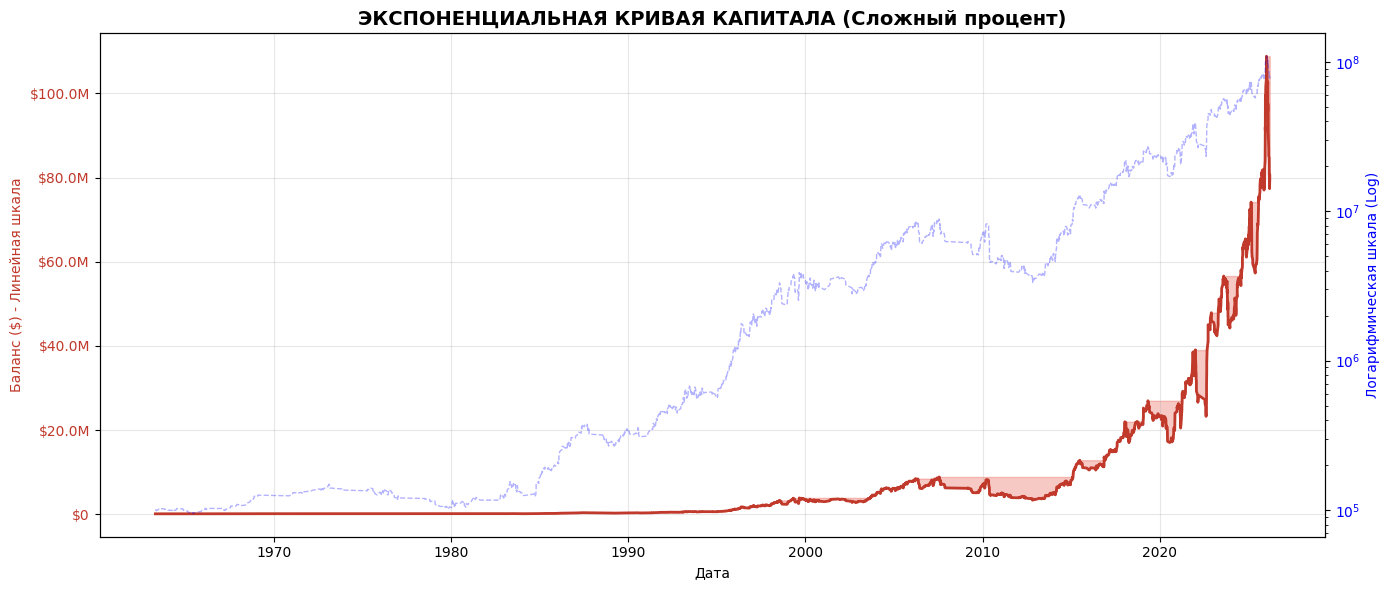

In [36]:
# ==============================================================================
# 🌌 FSD Engine (Phase 14): EXPONENTIAL COMPOUNDING (Сложный Процент)
# Макро-фильтр + Плечо 2x + Реинвестирование прибыли (Риск 10% на сделку)
# ==============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from tqdm.notebook import tqdm
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings("ignore")

class CompoundingBacktester:
    def __init__(self, tickers_f: list, tickers_a: list, initial_capital=100000, risk_per_trade=0.10, leverage=3):
        self.tickers_f = list(set(tickers_f)) 
        self.tickers_a = list(set(tickers_a)) 
        self.all_tickers = self.tickers_f + self.tickers_a
        self.initial_capital = initial_capital
        self.risk_per_trade = risk_per_trade # Инвестируем 10% от текущего банка
        self.leverage = leverage
        self.raw_trades = []
        
    def run_simulation(self):
        display(HTML(f"<p style='color:#e67e22; font-weight:bold;'>[*] Активация Сложного Процента. Загрузка вековой истории...</p>"))
        
        try:
            macro_data = yf.download("^GSPC", period="max", progress=False)['Close']
            if isinstance(macro_data, pd.DataFrame): macro_data = macro_data.squeeze()
            macro_sma200 = macro_data.rolling(200).mean()
            
            data = yf.download(self.all_tickers, period="max", progress=False)
        except Exception as e:
            display(HTML(f"<p style='color:#e74c3c;'>[!] Ошибка API: {e}</p>"))
            return

        for ticker in tqdm(self.all_tickers, desc="Сбор сигналов"):
            if isinstance(data.columns, pd.MultiIndex):
                if ticker in data.columns.get_level_values(1): df = data.xs(ticker, axis=1, level=1)
                elif ticker in data.columns.get_level_values(0): df = data[ticker]
                else: continue
            else: df = data

            df = df.dropna().copy()
            if len(df) < 250: continue

            df['Macro_Close'] = macro_data
            df['Macro_SMA200'] = macro_sma200
            df = df.dropna(subset=['Macro_SMA200'])

            df['Vol_USD'] = df['Close'] * df['Volume']
            roll_std = df['Vol_USD'].rolling(60).std().replace(0, 1e-9)
            z_scores = (df['Vol_USD'] - df['Vol_USD'].rolling(60).mean()) / roll_std
            df['P_Vol'] = 1 / (1 + np.exp(-z_scores * 1.5))
            
            sma20 = df['Close'].rolling(20).mean()
            std20 = df['Close'].rolling(20).std()
            lower_bb, upper_bb = sma20 - (std20 * 2), sma20 + (std20 * 2)
            df['Percent_B'] = (df['Close'] - lower_bb) / (upper_bb - lower_bb).replace(0, 1e-9)
            
            hl, hc, lc = df['High'] - df['Low'], np.abs(df['High'] - df['Close'].shift()), np.abs(df['Low'] - df['Close'].shift())
            df['ATR'] = pd.concat([hl, hc, lc], axis=1).max(axis=1).rolling(14).mean()
            
            df['Delta_1d'] = df['Close'].diff()
            df['Vector_1'] = np.select([df['Delta_1d'] >= df['ATR']/2, df['Delta_1d'] <= -df['ATR']/2], [1, -1], default=0)
            
            is_bull_market = df['Macro_Close'] > df['Macro_SMA200']
            
            if ticker in self.tickers_f:
                df['Vector_2'] = np.where(df['Close'].diff(3) > 0, 1, -1)
                signals = df[(df['P_Vol'] >= 0.65) & (df['Vector_1'] == 0) & (df['Vector_2'] == -1) & (df['Percent_B'] <= 0.15) & (is_bull_market)]
                trade_type = 'LONG'
            else:
                df['Vector_2'] = np.where(df['Close'].diff(3) > 0, 1, -1)
                signals = df[(df['P_Vol'] >= 0.65) & (df['Vector_1'] == 0) & (df['Vector_2'] == 1) & (df['Percent_B'] >= 0.85) & (~is_bull_market)]
                trade_type = 'SHORT'

            for idx, row in signals.iterrows():
                loc = df.index.get_loc(idx)
                if loc + 1 >= len(df): continue 
                
                entry_price, atr = row['Close'], row['ATR']
                sl = entry_price - (1.5 * atr) if trade_type == 'LONG' else entry_price + (1.5 * atr)
                tp = entry_price + (3.0 * atr) if trade_type == 'LONG' else entry_price - (3.0 * atr)

                exit_price, exit_date, exit_reason = None, None, "Time Stop"
                
                for i in range(1, 21):
                    if loc + i >= len(df): break
                    future_day = df.iloc[loc + i]
                    
                    if trade_type == 'LONG':
                        if future_day['Low'] <= sl: exit_price, exit_date, exit_reason = sl, df.index[loc + i], "Stop Loss"; break
                        elif future_day['High'] >= tp: exit_price, exit_date, exit_reason = tp, df.index[loc + i], "Take Profit"; break
                    else:
                        if future_day['High'] >= sl: exit_price, exit_date, exit_reason = sl, df.index[loc + i], "Stop Loss"; break
                        elif future_day['Low'] <= tp: exit_price, exit_date, exit_reason = tp, df.index[loc + i], "Take Profit"; break
                            
                if exit_price is None:
                    exit_idx = min(loc + 20, len(df) - 1)
                    exit_price, exit_date = df.iloc[exit_idx]['Close'], df.index[exit_idx]
                    
                self.raw_trades.append({
                    "Date": exit_date, "Type": trade_type, 
                    "Entry": entry_price, "Exit": exit_price, "Reason": exit_reason
                })

    def apply_compounding(self):
        trades_df = pd.DataFrame(self.raw_trades)
        if trades_df.empty:
            display(HTML("<h3>Сделок не найдено.</h3>"))
            return
            
        # Сортируем сделки хронологически для правильного реинвестирования
        trades_df = trades_df.sort_values(by="Date").reset_index(drop=True)
        
        current_equity = self.initial_capital
        equity_curve = []
        pnl_list = []
        
        for idx, row in trades_df.iterrows():
            # Рассчитываем размер позиции: 10% от текущего капитала * Плечо (2x)
            position_size = current_equity * self.risk_per_trade
            leveraged_size = position_size * self.leverage
            
            # Комиссия с полного объема
            commission = leveraged_size * 0.001 
            
            # Считаем сырую процентную доходность сделки
            if row['Type'] == 'LONG':
                trade_return_pct = (row['Exit'] - row['Entry']) / row['Entry']
            else:
                trade_return_pct = (row['Entry'] - row['Exit']) / row['Entry']
                
            # Итоговый PnL сделки в долларах
            trade_pnl = (leveraged_size * trade_return_pct) - commission
            
            current_equity += trade_pnl
            
            # Защита от маржин-колла (баланс не может быть меньше 0)
            if current_equity <= 0:
                current_equity = 0
                pnl_list.append(trade_pnl)
                equity_curve.append(current_equity)
                break
                
            pnl_list.append(trade_pnl)
            equity_curve.append(current_equity)
            
        trades_df = trades_df.iloc[:len(equity_curve)] # Обрезаем, если был маржин-колл
        trades_df['PnL'] = pnl_list
        trades_df['Equity'] = equity_curve
        
        # Расчет метрик
        trades_df['Running_Max'] = trades_df['Equity'].cummax()
        trades_df['Drawdown'] = (trades_df['Equity'] - trades_df['Running_Max']) / trades_df['Running_Max'] * 100
        max_drawdown = trades_df['Drawdown'].min()
        
        final_equity = trades_df['Equity'].iloc[-1]
        total_trades = len(trades_df)
        win_rate = (len(trades_df[trades_df['PnL'] > 0]) / total_trades) * 100
        
        # ROI в "иксах" или процентах
        roi_multiplier = final_equity / self.initial_capital
        
        first_year = trades_df['Date'].iloc[0].year
        last_year = trades_df['Date'].iloc[-1].year
        
        display(HTML(f"<h2>🔥 СЛОЖНЫЙ ПРОЦЕНТ ({first_year} - {last_year}) | Реинвест 10% | Плечо {self.leverage}X</h2>"))
        
        html = f"""
        <table style='width:100%; text-align:center; border-collapse: collapse; font-family: sans-serif; font-size: 16px;'>
            <tr style='background:#c0392b; color:white;'>
                <th style='padding:15px;'>Всего Сделок</th>
                <th style='padding:15px;'>WinRate</th>
                <th style='padding:15px;'>Старт</th>
                <th style='padding:15px;'>Итоговый Баланс</th>
                <th style='padding:15px;'>Рост Капитала</th>
                <th style='padding:15px;'>Max Просадка</th>
            </tr>
            <tr>
                <td style='padding:15px; border-bottom: 1px solid #ddd;'><b>{total_trades}</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:{'#2ecc71' if win_rate > 40 else '#e74c3c'}'><b>{win_rate:.1f}%</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd;'><b>${self.initial_capital:,.0f}</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:#2ecc71; font-size:1.2em;'><b>${final_equity:,.0f}</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:#2ecc71;'><b>{roi_multiplier:,.1f}x (Иксов)</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:#e74c3c;'><b>{max_drawdown:.2f}%</b></td>
            </tr>
        </table>
        """
        display(HTML(html))

        # Отрисовка Экспоненциальной Кривой Капитала
        fig, ax1 = plt.subplots(figsize=(14, 6))
        
        ax1.plot(trades_df['Date'], trades_df['Equity'], color='#c0392b', linewidth=2)
        ax1.set_title(f'ЭКСПОНЕНЦИАЛЬНАЯ КРИВАЯ КАПИТАЛА (Сложный процент)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Дата')
        ax1.set_ylabel('Баланс ($) - Линейная шкала', color='#c0392b')
        ax1.tick_params(axis='y', labelcolor='#c0392b')
        
        # Форматирование оси Y в миллионы/миллиарды для читаемости
        formatter = ticker.FuncFormatter(lambda x, pos: f'${x*1e-6:,.1f}M' if x >= 1e6 else f'${x:,.0f}')
        ax1.yaxis.set_major_formatter(formatter)
        
        ax1.grid(alpha=0.3)
        plt.fill_between(trades_df['Date'], trades_df['Equity'], trades_df['Running_Max'], color='#e74c3c', alpha=0.3, label='Просадка')
        
        # Добавляем логарифмическую шкалу на вторую ось для оценки стабильности роста
        ax2 = ax1.twinx()
        ax2.plot(trades_df['Date'], trades_df['Equity'], color='blue', linewidth=1, alpha=0.3, linestyle='--')
        ax2.set_yscale('log')
        ax2.set_ylabel('Логарифмическая шкала (Log)', color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')
        
        fig.tight_layout()
        plt.show()

# ==============================================================================
# ЗАПУСК ЭКСПЕРИМЕНТА
# ==============================================================================
F_TICKERS = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA", "JPM", "V", "JNJ", "WMT", "PG", "MA", "HD", "CVX", "MRK", "ABBV", "PEP", "KO", "BAC", "TMO", "COST", "CSCO", "MCD", "CRM", "DIS", "QCOM", "BLK", "ADI", "DHR"]
A_TICKERS = ["BTC-USD", "ETH-USD", "SOL-USD", "DOGE-USD", "GME", "AMC", "CVNA", "DJT", "MSTR", "HOOD", "COIN", "RIVN"]

# initial_capital = 100 000
# risk_per_trade = 0.10 (Берем 10% от депо)
# leverage = 2 (Умножаем ставку на 2)
compounding_test = CompoundingBacktester(tickers_f=F_TICKERS, tickers_a=A_TICKERS, initial_capital=100000, risk_per_trade=0.10, leverage=3)
compounding_test.run_simulation()
compounding_test.apply_compounding()

Анализ с учетом ставки ЦБ:   0%|          | 0/42 [00:00<?, ?it/s]

WinRate,Заработано от ФРС (Кэш),Итоговый Баланс,Рост Капитала,Max Просадка
45.5%,"+$1,238,461,208","$9,294,022,175","92,940.2x (Иксов)",-72.28%


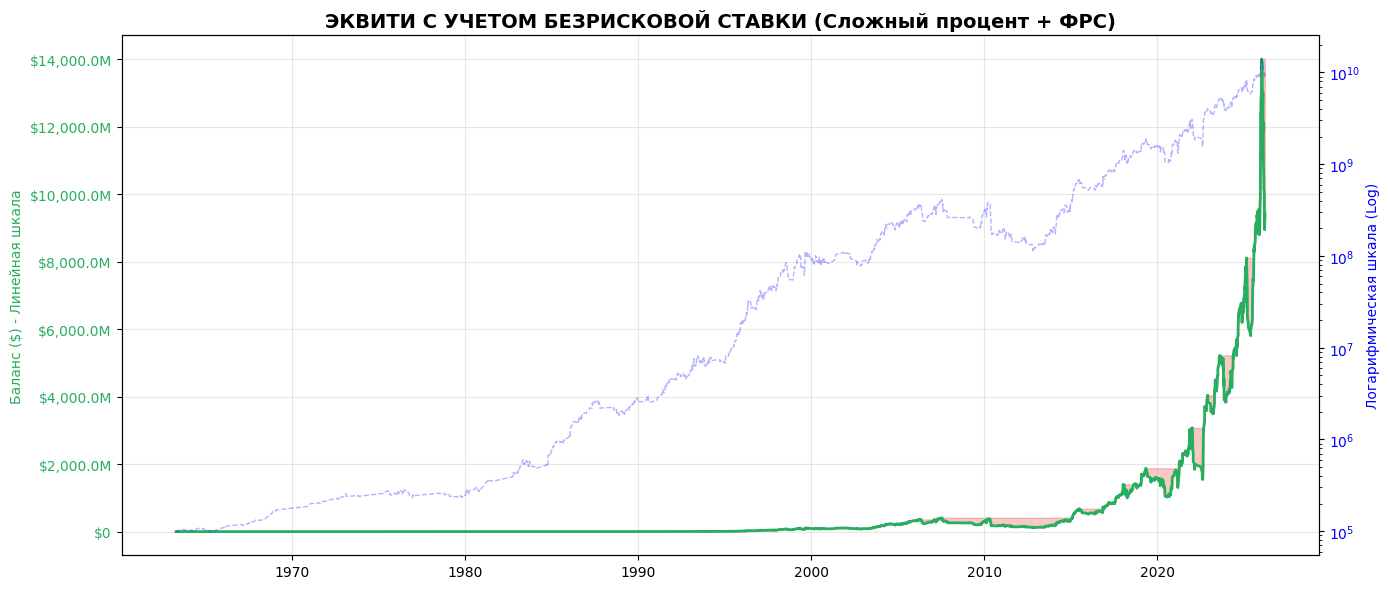

In [41]:
# ==============================================================================
# 🌌 FSD Engine (Phase 15): THE HOLY GRAIL (Compounding + Risk-Free Interest)
# Макро-фильтр + Плечо + Реинвест + Ежедневный процент на свободный кэш (ФРС США)
# ==============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from tqdm.notebook import tqdm
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings("ignore")

class TreasuryCompoundingBacktester:
    def __init__(self, tickers_f: list, tickers_a: list, initial_capital=100000, risk_per_trade=0.10, leverage=4):
        self.tickers_f = list(set(tickers_f)) 
        self.tickers_a = list(set(tickers_a)) 
        self.all_tickers = self.tickers_f + self.tickers_a
        self.initial_capital = initial_capital
        self.risk_per_trade = risk_per_trade 
        self.leverage = leverage
        self.raw_trades = []
        self.irx_data = pd.Series(dtype='float64')
        
    def run_simulation(self):
        display(HTML(f"<p style='color:#27ae60; font-weight:bold;'>[*] Подключение к ФРС США. Загрузка безрисковых ставок (^IRX) и истории...</p>"))
        
        try:
            # 1. Загружаем макро-фильтр S&P 500
            macro_data = yf.download("^GSPC", period="max", progress=False)['Close']
            if isinstance(macro_data, pd.DataFrame): macro_data = macro_data.squeeze()
            macro_sma200 = macro_data.rolling(200).mean()
            
            # 2. Загружаем ставку ЦБ (13-week T-Bill). Значения в процентах (напр. 5.0 = 5%)
            irx = yf.download("^IRX", period="max", progress=False)['Close']
            if isinstance(irx, pd.DataFrame): irx = irx.squeeze()
            self.irx_data = irx.ffill().dropna() # Заполняем пустоты
            
            # 3. Загружаем активы
            data = yf.download(self.all_tickers, period="max", progress=False)
        except Exception as e:
            display(HTML(f"<p style='color:#e74c3c;'>[!] Ошибка API: {e}</p>"))
            return

        for ticker in tqdm(self.all_tickers, desc="Анализ с учетом ставки ЦБ"):
            if isinstance(data.columns, pd.MultiIndex):
                if ticker in data.columns.get_level_values(1): df = data.xs(ticker, axis=1, level=1)
                elif ticker in data.columns.get_level_values(0): df = data[ticker]
                else: continue
            else: df = data

            df = df.dropna().copy()
            if len(df) < 250: continue

            df['Macro_Close'] = macro_data
            df['Macro_SMA200'] = macro_sma200
            df = df.dropna(subset=['Macro_SMA200'])

            # Физика
            df['Vol_USD'] = df['Close'] * df['Volume']
            roll_std = df['Vol_USD'].rolling(60).std().replace(0, 1e-9)
            z_scores = (df['Vol_USD'] - df['Vol_USD'].rolling(60).mean()) / roll_std
            df['P_Vol'] = 1 / (1 + np.exp(-z_scores * 1.5))
            
            sma20 = df['Close'].rolling(20).mean()
            std20 = df['Close'].rolling(20).std()
            lower_bb, upper_bb = sma20 - (std20 * 2), sma20 + (std20 * 2)
            df['Percent_B'] = (df['Close'] - lower_bb) / (upper_bb - lower_bb).replace(0, 1e-9)
            
            hl, hc, lc = df['High'] - df['Low'], np.abs(df['High'] - df['Close'].shift()), np.abs(df['Low'] - df['Close'].shift())
            df['ATR'] = pd.concat([hl, hc, lc], axis=1).max(axis=1).rolling(14).mean()
            
            df['Delta_1d'] = df['Close'].diff()
            df['Vector_1'] = np.select([df['Delta_1d'] >= df['ATR']/2, df['Delta_1d'] <= -df['ATR']/2], [1, -1], default=0)
            
            is_bull_market = df['Macro_Close'] > df['Macro_SMA200']
            
            if ticker in self.tickers_f:
                df['Vector_2'] = np.where(df['Close'].diff(3) > 0, 1, -1)
                signals = df[(df['P_Vol'] >= 0.65) & (df['Vector_1'] == 0) & (df['Vector_2'] == -1) & (df['Percent_B'] <= 0.15) & (is_bull_market)]
                trade_type = 'LONG'
            else:
                df['Vector_2'] = np.where(df['Close'].diff(3) > 0, 1, -1)
                signals = df[(df['P_Vol'] >= 0.65) & (df['Vector_1'] == 0) & (df['Vector_2'] == 1) & (df['Percent_B'] >= 0.85) & (~is_bull_market)]
                trade_type = 'SHORT'

            for idx, row in signals.iterrows():
                loc = df.index.get_loc(idx)
                if loc + 1 >= len(df): continue 
                
                entry_price, atr = row['Close'], row['ATR']
                sl = entry_price - (1.5 * atr) if trade_type == 'LONG' else entry_price + (1.5 * atr)
                tp = entry_price + (3.0 * atr) if trade_type == 'LONG' else entry_price - (3.0 * atr)

                exit_price, exit_date, exit_reason = None, None, "Time Stop"
                
                for i in range(1, 21):
                    if loc + i >= len(df): break
                    future_day = df.iloc[loc + i]
                    
                    if trade_type == 'LONG':
                        if future_day['Low'] <= sl: exit_price, exit_date, exit_reason = sl, df.index[loc + i], "Stop Loss"; break
                        elif future_day['High'] >= tp: exit_price, exit_date, exit_reason = tp, df.index[loc + i], "Take Profit"; break
                    else:
                        if future_day['High'] >= sl: exit_price, exit_date, exit_reason = sl, df.index[loc + i], "Stop Loss"; break
                        elif future_day['Low'] <= tp: exit_price, exit_date, exit_reason = tp, df.index[loc + i], "Take Profit"; break
                            
                if exit_price is None:
                    exit_idx = min(loc + 20, len(df) - 1)
                    exit_price, exit_date = df.iloc[exit_idx]['Close'], df.index[exit_idx]
                    
                self.raw_trades.append({
                    "Date": exit_date, "Entry_Date": idx, "Type": trade_type, 
                    "Entry": entry_price, "Exit": exit_price, "Reason": exit_reason
                })

    def apply_compounding_with_interest(self):
        trades_df = pd.DataFrame(self.raw_trades)
        if trades_df.empty:
            display(HTML("<h3>Сделок не найдено.</h3>"))
            return
            
        trades_df = trades_df.sort_values(by="Date").reset_index(drop=True)
        
        current_equity = self.initial_capital
        total_interest_earned = 0.0
        
        equity_curve = []
        pnl_list = []
        interest_list = []
        
        # Определяем стартовую дату симуляции
        last_date = trades_df['Entry_Date'].min()
        
        for idx, row in trades_df.iterrows():
            current_date = row['Date']
            
            # 1. НАЧИСЛЕНИЕ ПРОЦЕНТОВ ФРС НА ПРОСТАИВАЮЩИЙ КЭШ
            trade_interest = 0.0
            if current_date > last_date:
                # Берем ставки за прошедшие дни между сделками
                period_rates = self.irx_data.loc[last_date:current_date]
                if not period_rates.empty:
                    # Кэш, который не в сделке (90% от капитала)
                    idle_cash = current_equity * (1 - self.risk_per_trade)
                    # Суммируем ежедневную ставку (Годовая ставка / 100 / 252 торговых дня)
                    total_rate_pct = (period_rates / 100 / 252).sum()
                    trade_interest = idle_cash * total_rate_pct
                    
                    current_equity += trade_interest
                    total_interest_earned += trade_interest
            
            last_date = current_date
            
            # 2. РАСЧЕТ PnL СДЕЛКИ С ПЛЕЧОМ
            position_size = current_equity * self.risk_per_trade
            leveraged_size = position_size * self.leverage
            commission = leveraged_size * 0.001 
            
            if row['Type'] == 'LONG': trade_return_pct = (row['Exit'] - row['Entry']) / row['Entry']
            else: trade_return_pct = (row['Entry'] - row['Exit']) / row['Entry']
                
            trade_pnl = (leveraged_size * trade_return_pct) - commission
            current_equity += trade_pnl
            
            if current_equity <= 0:
                current_equity = 0
                pnl_list.append(trade_pnl)
                interest_list.append(trade_interest)
                equity_curve.append(current_equity)
                break
                
            pnl_list.append(trade_pnl)
            interest_list.append(trade_interest)
            equity_curve.append(current_equity)
            
        trades_df = trades_df.iloc[:len(equity_curve)]
        trades_df['PnL'] = pnl_list
        trades_df['Equity'] = equity_curve
        
        trades_df['Running_Max'] = trades_df['Equity'].cummax()
        trades_df['Drawdown'] = (trades_df['Equity'] - trades_df['Running_Max']) / trades_df['Running_Max'] * 100
        max_drawdown = trades_df['Drawdown'].min()
        
        final_equity = trades_df['Equity'].iloc[-1]
        total_trades = len(trades_df)
        win_rate = (len(trades_df[trades_df['PnL'] > 0]) / total_trades) * 100
        roi_multiplier = final_equity / self.initial_capital
        
        first_year = trades_df['Date'].iloc[0].year
        last_year = trades_df['Date'].iloc[-1].year
        
        display(HTML(f"<h2>🏛️ THE HOLY GRAIL ({first_year} - {last_year}) | Реинвест 10% | Плечо {self.leverage}X | + Ставка ФРС</h2>"))
        
        html = f"""
        <table style='width:100%; text-align:center; border-collapse: collapse; font-family: sans-serif; font-size: 16px;'>
            <tr style='background:#27ae60; color:white;'>
                <th style='padding:15px;'>WinRate</th>
                <th style='padding:15px;'>Заработано от ФРС (Кэш)</th>
                <th style='padding:15px;'>Итоговый Баланс</th>
                <th style='padding:15px;'>Рост Капитала</th>
                <th style='padding:15px;'>Max Просадка</th>
            </tr>
            <tr>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:{'#2ecc71' if win_rate > 40 else '#e74c3c'}'><b>{win_rate:.1f}%</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:#2ecc71;'><b>+${total_interest_earned:,.0f}</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:#27ae60; font-size:1.2em;'><b>${final_equity:,.0f}</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:#27ae60;'><b>{roi_multiplier:,.1f}x (Иксов)</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:#e74c3c;'><b>{max_drawdown:.2f}%</b></td>
            </tr>
        </table>
        """
        display(HTML(html))

        fig, ax1 = plt.subplots(figsize=(14, 6))
        ax1.plot(trades_df['Date'], trades_df['Equity'], color='#27ae60', linewidth=2)
        ax1.set_title(f'ЭКВИТИ С УЧЕТОМ БЕЗРИСКОВОЙ СТАВКИ (Сложный процент + ФРС)', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Баланс ($) - Линейная шкала', color='#27ae60')
        ax1.tick_params(axis='y', labelcolor='#27ae60')
        formatter = ticker.FuncFormatter(lambda x, pos: f'${x*1e-6:,.1f}M' if x >= 1e6 else f'${x:,.0f}')
        ax1.yaxis.set_major_formatter(formatter)
        ax1.grid(alpha=0.3)
        plt.fill_between(trades_df['Date'], trades_df['Equity'], trades_df['Running_Max'], color='#e74c3c', alpha=0.3, label='Просадка')
        
        ax2 = ax1.twinx()
        ax2.plot(trades_df['Date'], trades_df['Equity'], color='blue', linewidth=1, alpha=0.3, linestyle='--')
        ax2.set_yscale('log')
        ax2.set_ylabel('Логарифмическая шкала (Log)', color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')
        
        fig.tight_layout()
        plt.show()

# ==============================================================================
# ЗАПУСК ФИНАЛЬНОЙ СИМУЛЯЦИИ
# ==============================================================================
F_TICKERS = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA", "JPM", "V", "JNJ", "WMT", "PG", "MA", "HD", "CVX", "MRK", "ABBV", "PEP", "KO", "BAC", "TMO", "COST", "CSCO", "MCD", "CRM", "DIS", "QCOM", "BLK", "ADI", "DHR"]
A_TICKERS = ["BTC-USD", "ETH-USD", "SOL-USD", "DOGE-USD", "GME", "AMC", "CVNA", "DJT", "MSTR", "HOOD", "COIN", "RIVN"]

holy_grail = TreasuryCompoundingBacktester(tickers_f=F_TICKERS, tickers_a=A_TICKERS, initial_capital=100000, risk_per_trade=0.10, leverage=4)
holy_grail.run_simulation()
holy_grail.apply_compounding_with_interest()

Извлечение сигналов:   0%|          | 0/42 [00:00<?, ?it/s]

WinRate,Кэш от ФРС (^IRX),Итоговый Баланс,Чистая Доходность,Max Просадка
45.8%,"+$210,248","$1,679,574","+1,579.6%",-49.74%


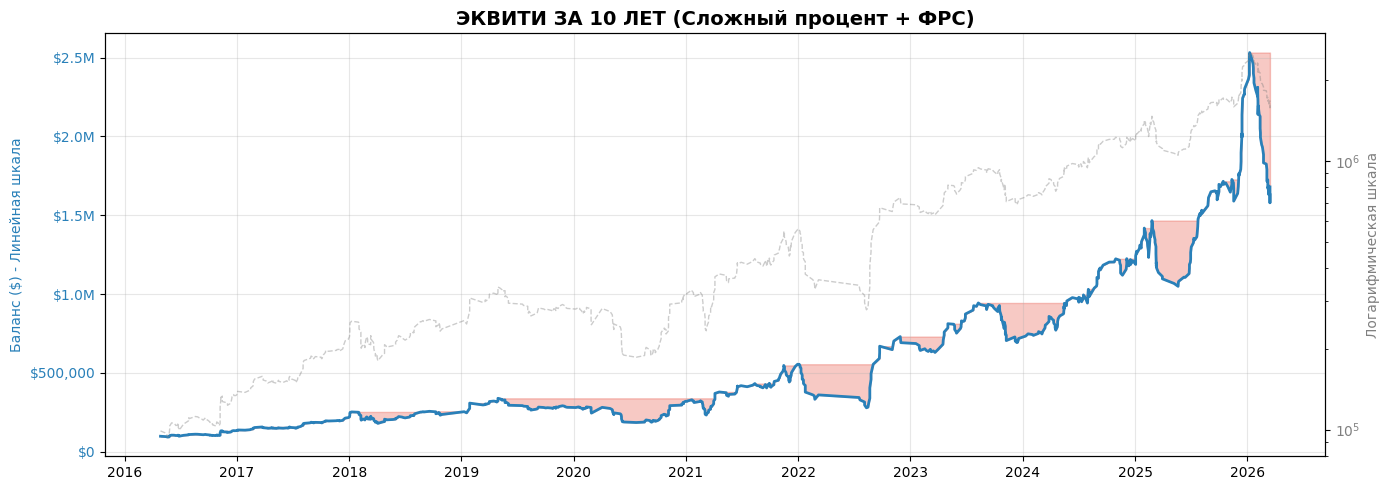

WinRate,Кэш от ФРС (^IRX),Итоговый Баланс,Чистая Доходность,Max Просадка
45.4%,"+$52,962","$453,431",+353.4%,-49.74%


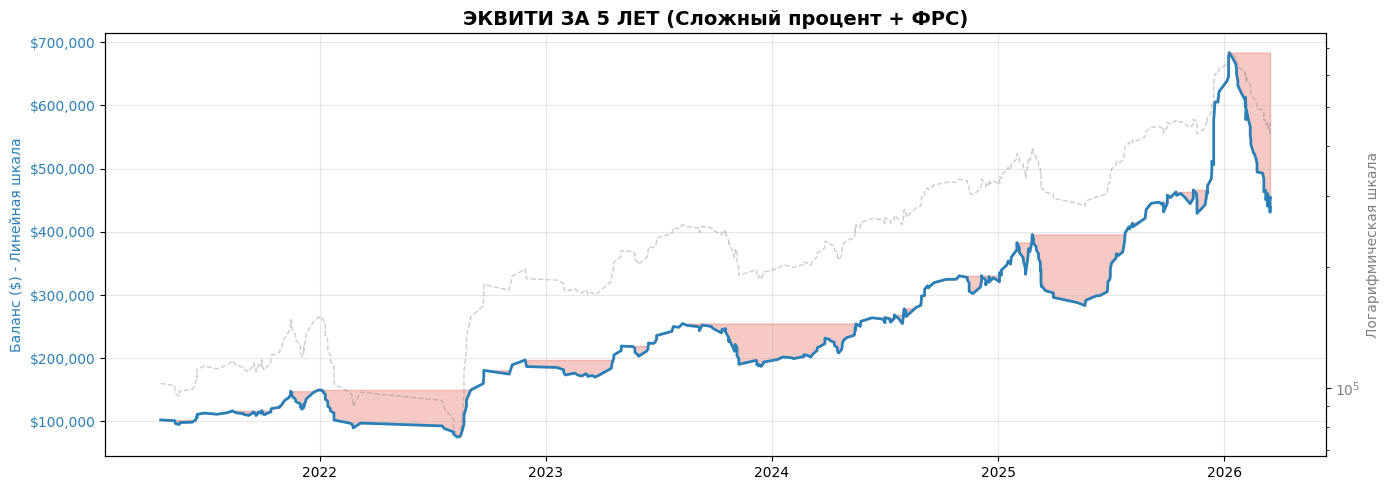

In [45]:
# ==============================================================================
# 🌌 FSD Engine (Phase 16): INSTITUTIONAL TRACK RECORD (5Y & 10Y)
# Срезы за 5 и 10 лет | Реинвест 10% | Ставка ФРС | Плечо 2x
# ==============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from tqdm.notebook import tqdm
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings("ignore")

class InstitutionalBacktester:
    def __init__(self, tickers_f: list, tickers_a: list, initial_capital=100000, risk_per_trade=0.10, leverage=4):
        self.tickers_f = list(set(tickers_f)) 
        self.tickers_a = list(set(tickers_a)) 
        self.all_tickers = self.tickers_f + self.tickers_a
        self.initial_capital = initial_capital
        self.risk_per_trade = risk_per_trade 
        self.leverage = leverage
        self.raw_trades = []
        self.irx_data = pd.Series(dtype='float64')
        
    def run_simulation(self, max_years=10):
        # Загружаем 10 лет + буфер 300 дней для расчета SMA 200 на старте
        fetch_days = (max_years * 252) + 300 
        display(HTML(f"<p style='color:#2980b9; font-weight:bold;'>[*] Загрузка данных за последние {max_years} лет. Подготовка двойного отчета...</p>"))
        
        try:
            macro_data = yf.download("^GSPC", period=f"{fetch_days}d", progress=False)['Close']
            if isinstance(macro_data, pd.DataFrame): macro_data = macro_data.squeeze()
            macro_sma200 = macro_data.rolling(200).mean()
            
            irx = yf.download("^IRX", period=f"{fetch_days}d", progress=False)['Close']
            if isinstance(irx, pd.DataFrame): irx = irx.squeeze()
            self.irx_data = irx.ffill().dropna() 
            
            data = yf.download(self.all_tickers, period=f"{fetch_days}d", progress=False)
        except Exception as e:
            display(HTML(f"<p style='color:#e74c3c;'>[!] Ошибка API: {e}</p>"))
            return

        for ticker in tqdm(self.all_tickers, desc="Извлечение сигналов"):
            if isinstance(data.columns, pd.MultiIndex):
                if ticker in data.columns.get_level_values(1): df = data.xs(ticker, axis=1, level=1)
                elif ticker in data.columns.get_level_values(0): df = data[ticker]
                else: continue
            else: df = data

            df = df.dropna().copy()
            if len(df) < 250: continue

            df['Macro_Close'] = macro_data
            df['Macro_SMA200'] = macro_sma200
            df = df.dropna(subset=['Macro_SMA200'])

            df['Vol_USD'] = df['Close'] * df['Volume']
            roll_std = df['Vol_USD'].rolling(60).std().replace(0, 1e-9)
            z_scores = (df['Vol_USD'] - df['Vol_USD'].rolling(60).mean()) / roll_std
            df['P_Vol'] = 1 / (1 + np.exp(-z_scores * 1.5))
            
            sma20 = df['Close'].rolling(20).mean()
            std20 = df['Close'].rolling(20).std()
            lower_bb, upper_bb = sma20 - (std20 * 2), sma20 + (std20 * 2)
            df['Percent_B'] = (df['Close'] - lower_bb) / (upper_bb - lower_bb).replace(0, 1e-9)
            
            hl, hc, lc = df['High'] - df['Low'], np.abs(df['High'] - df['Close'].shift()), np.abs(df['Low'] - df['Close'].shift())
            df['ATR'] = pd.concat([hl, hc, lc], axis=1).max(axis=1).rolling(14).mean()
            
            df['Delta_1d'] = df['Close'].diff()
            df['Vector_1'] = np.select([df['Delta_1d'] >= df['ATR']/2, df['Delta_1d'] <= -df['ATR']/2], [1, -1], default=0)
            
            is_bull_market = df['Macro_Close'] > df['Macro_SMA200']
            
            if ticker in self.tickers_f:
                df['Vector_2'] = np.where(df['Close'].diff(3) > 0, 1, -1)
                signals = df[(df['P_Vol'] >= 0.65) & (df['Vector_1'] == 0) & (df['Vector_2'] == -1) & (df['Percent_B'] <= 0.15) & (is_bull_market)]
                trade_type = 'LONG'
            else:
                df['Vector_2'] = np.where(df['Close'].diff(3) > 0, 1, -1)
                signals = df[(df['P_Vol'] >= 0.65) & (df['Vector_1'] == 0) & (df['Vector_2'] == 1) & (df['Percent_B'] >= 0.85) & (~is_bull_market)]
                trade_type = 'SHORT'

            for idx, row in signals.iterrows():
                loc = df.index.get_loc(idx)
                if loc + 1 >= len(df): continue 
                
                entry_price, atr = row['Close'], row['ATR']
                sl = entry_price - (1.5 * atr) if trade_type == 'LONG' else entry_price + (1.5 * atr)
                tp = entry_price + (3.0 * atr) if trade_type == 'LONG' else entry_price - (3.0 * atr)

                exit_price, exit_date, exit_reason = None, None, "Time Stop"
                
                for i in range(1, 21):
                    if loc + i >= len(df): break
                    future_day = df.iloc[loc + i]
                    
                    if trade_type == 'LONG':
                        if future_day['Low'] <= sl: exit_price, exit_date, exit_reason = sl, df.index[loc + i], "Stop Loss"; break
                        elif future_day['High'] >= tp: exit_price, exit_date, exit_reason = tp, df.index[loc + i], "Take Profit"; break
                    else:
                        if future_day['High'] >= sl: exit_price, exit_date, exit_reason = sl, df.index[loc + i], "Stop Loss"; break
                        elif future_day['Low'] <= tp: exit_price, exit_date, exit_reason = tp, df.index[loc + i], "Take Profit"; break
                            
                if exit_price is None:
                    exit_idx = min(loc + 20, len(df) - 1)
                    exit_price, exit_date = df.iloc[exit_idx]['Close'], df.index[exit_idx]
                    
                self.raw_trades.append({
                    "Date": exit_date, "Entry_Date": idx, "Type": trade_type, 
                    "Entry": entry_price, "Exit": exit_price, "Reason": exit_reason
                })

    def apply_compounding_with_interest(self, years):
        # Безопасный расчет даты отсечения, чтобы избежать ошибок таймзон
        if self.irx_data.empty or not self.raw_trades: return
        
        last_market_date = self.irx_data.index[-1]
        cutoff_date = last_market_date - pd.Timedelta(days=years*365)
        
        # Фильтруем сделки строго за нужный период
        filtered_raw = [t for t in self.raw_trades if t['Entry_Date'] >= cutoff_date]
        trades_df = pd.DataFrame(filtered_raw)
        
        if trades_df.empty:
            display(HTML(f"<h3>Сделок за {years} лет не найдено.</h3>"))
            return
            
        trades_df = trades_df.sort_values(by="Date").reset_index(drop=True)
        
        current_equity = self.initial_capital
        total_interest_earned = 0.0
        
        equity_curve, pnl_list, interest_list = [], [], []
        
        last_date = trades_df['Entry_Date'].min()
        
        for idx, row in trades_df.iterrows():
            current_date = row['Date']
            
            # Проценты ФРС на простаивающий кэш
            trade_interest = 0.0
            if current_date > last_date:
                period_rates = self.irx_data.loc[last_date:current_date]
                if not period_rates.empty:
                    idle_cash = current_equity * (1 - self.risk_per_trade)
                    total_rate_pct = (period_rates / 100 / 252).sum()
                    trade_interest = idle_cash * total_rate_pct
                    current_equity += trade_interest
                    total_interest_earned += trade_interest
            
            last_date = current_date
            
            # PnL Сделки
            position_size = current_equity * self.risk_per_trade
            leveraged_size = position_size * self.leverage
            commission = leveraged_size * 0.001 
            
            if row['Type'] == 'LONG': trade_return_pct = (row['Exit'] - row['Entry']) / row['Entry']
            else: trade_return_pct = (row['Entry'] - row['Exit']) / row['Entry']
                
            trade_pnl = (leveraged_size * trade_return_pct) - commission
            current_equity += trade_pnl
            
            if current_equity <= 0:
                current_equity = 0
                pnl_list.append(trade_pnl); interest_list.append(trade_interest); equity_curve.append(current_equity)
                break
                
            pnl_list.append(trade_pnl); interest_list.append(trade_interest); equity_curve.append(current_equity)
            
        trades_df = trades_df.iloc[:len(equity_curve)]
        trades_df['PnL'] = pnl_list
        trades_df['Equity'] = equity_curve
        
        trades_df['Running_Max'] = trades_df['Equity'].cummax()
        trades_df['Drawdown'] = (trades_df['Equity'] - trades_df['Running_Max']) / trades_df['Running_Max'] * 100
        max_drawdown = trades_df['Drawdown'].min()
        
        final_equity = trades_df['Equity'].iloc[-1]
        total_trades = len(trades_df)
        win_rate = (len(trades_df[trades_df['PnL'] > 0]) / total_trades) * 100
        roi_pct = ((final_equity - self.initial_capital) / self.initial_capital) * 100
        
        display(HTML(f"<h2>📅 РЕТРОСПЕКТИВА ЗА {years} ЛЕТ | Старт $100k | Реинвест 10% | Плечо {self.leverage}X</h2>"))
        
        html = f"""
        <table style='width:100%; text-align:center; border-collapse: collapse; font-family: sans-serif; font-size: 16px;'>
            <tr style='background:#2980b9; color:white;'>
                <th style='padding:15px;'>WinRate</th>
                <th style='padding:15px;'>Кэш от ФРС (^IRX)</th>
                <th style='padding:15px;'>Итоговый Баланс</th>
                <th style='padding:15px;'>Чистая Доходность</th>
                <th style='padding:15px;'>Max Просадка</th>
            </tr>
            <tr>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:{'#2ecc71' if win_rate > 40 else '#e74c3c'}'><b>{win_rate:.1f}%</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:#2980b9;'><b>+${total_interest_earned:,.0f}</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:#27ae60; font-size:1.2em;'><b>${final_equity:,.0f}</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:#27ae60;'><b>+{roi_pct:,.1f}%</b></td>
                <td style='padding:15px; border-bottom: 1px solid #ddd; color:#e74c3c;'><b>{max_drawdown:.2f}%</b></td>
            </tr>
        </table>
        """
        display(HTML(html))

        fig, ax1 = plt.subplots(figsize=(14, 5))
        ax1.plot(trades_df['Date'], trades_df['Equity'], color='#2980b9', linewidth=2)
        ax1.set_title(f'ЭКВИТИ ЗА {years} ЛЕТ (Сложный процент + ФРС)', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Баланс ($) - Линейная шкала', color='#2980b9')
        ax1.tick_params(axis='y', labelcolor='#2980b9')
        formatter = ticker.FuncFormatter(lambda x, pos: f'${x*1e-6:,.1f}M' if x >= 1e6 else f'${x:,.0f}')
        ax1.yaxis.set_major_formatter(formatter)
        ax1.grid(alpha=0.3)
        plt.fill_between(trades_df['Date'], trades_df['Equity'], trades_df['Running_Max'], color='#e74c3c', alpha=0.3, label='Просадка')
        
        ax2 = ax1.twinx()
        ax2.plot(trades_df['Date'], trades_df['Equity'], color='grey', linewidth=1, alpha=0.4, linestyle='--')
        ax2.set_yscale('log')
        ax2.set_ylabel('Логарифмическая шкала', color='grey')
        ax2.tick_params(axis='y', labelcolor='grey')
        
        fig.tight_layout()
        plt.show()

# ==============================================================================
# ЗАПУСК ФИНАЛЬНОГО ОТЧЕТА (5 И 10 ЛЕТ)
# ==============================================================================
F_TICKERS = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA", "JPM", "V", "JNJ", "WMT", "PG", "MA", "HD", "CVX", "MRK", "ABBV", "PEP", "KO", "BAC", "TMO", "COST", "CSCO", "MCD", "CRM", "DIS", "QCOM", "BLK", "ADI", "DHR"]
A_TICKERS = ["BTC-USD", "ETH-USD", "SOL-USD", "DOGE-USD", "GME", "AMC", "CVNA", "DJT", "MSTR", "HOOD", "COIN", "RIVN"]

# Создаем симулятор с 2-м плечом (можно поменять на 3 для большей агрессии)
inst_backtester = InstitutionalBacktester(tickers_f=F_TICKERS, tickers_a=A_TICKERS, initial_capital=100000, risk_per_trade=0.10, leverage=4)

# Загружаем данные один раз (за 10 лет)
inst_backtester.run_simulation(max_years=10)

# Генерируем два независимых отчета
inst_backtester.apply_compounding_with_interest(years=10)
inst_backtester.apply_compounding_with_interest(years=5)